In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import simpson

In [2]:
plt.rcParams.update({
    "figure.figsize": (10, 10),
    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 28,
    "lines.linewidth": 2,
    "axes.grid": False,
})

# Timed stimulation

In [3]:
def time_2first_ord(t, x, glut_type=0, t2=10000, taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5, amp=1, scaleglu=1):
    
    X = x[0]
    U = x[1]
    K = x[2]
    g = x[3]
    
    

#   Periodic square pulses
    if glut_type == 0:
        if t%(1000/t2)<=1:
            glutamate = 1
        else:
            glutamate = 0



    if glut_type == 1:
        if t%(1000/t2)<=1 and t<1000/t2*20:
            glutamate = 1
        else:
            glutamate = 0

        
#   Paired Square Pulse
    if glut_type == 2:
        if t>=0 and t<50 or t>=t2 and t<50+t2:   
            glutamate = 1
        else:
            glutamate = 0

            
#   Square pulse of certain length
    if glut_type == 3:
        if t>=0 and t<t2:  
            glutamate = 1
        else:
            glutamate = 0

    # Inputting array of timepoints fr t2
    if glut_type == 4:
        if np.any((t >= t2) & (t < t2 + 1.0)):
            glutamate = 1.0
        else:
            glutamate = 0.0      



   

    
    U_plus = U #+ (U_0 * (1.0 - U))*glutamate
    dU = (U_0 - U)/tauu + (U_0 * (1.0 - U))*glutamate*scaleglu
    
    dX = (1-X)/taux - (alpha * U_plus * X)*glutamate*scaleglu

        
    dK = -K/tauK + (A1 * U_plus * X)*glutamate*scaleglu
    dg = -g/taug + (A2 * U_plus * X)*glutamate*scaleglu


    return np.array([dX, dU, dK, dg])

In [4]:
def time_2first_ordvar(t, x, taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.55, burst_len=300):
    
    X = x[0]
    U = x[1]
    K = x[2]
    g = x[3]
    

    if t%(1000/5)<=1 and t<burst_len:
        glutamate = 1
    elif t%(1000/(2*5))<=1 and t<2*burst_len and t>=burst_len:
        glutamate = 1
    elif t%(1000/(4*5))<=1 and t<3*burst_len and t>=2*burst_len:
        glutamate = 1
    elif t%(1000/(10*5))<=1 and t<4*burst_len and t>=3*burst_len:
        glutamate = 1
    elif t%(1000/(20*5))<=1 and t<5*burst_len and t>=4*burst_len:
        glutamate = 1
    elif t%(1000/(40*5))<=1 and t<6*burst_len and t>=5*burst_len:
        glutamate = 1
    elif t%(1000/(60*5))<=1 and t<7*burst_len and t>=6*burst_len:
        glutamate = 1
    elif t%(1000/(80*5))<=1 and t<8*burst_len and t>=7*burst_len:
        glutamate = 1
    elif t%(1000/(100*5))<=1 and t<9*burst_len and t>=8*burst_len:
        glutamate = 1
    else:
        glutamate = 0

    
    dU = (U_0 - U)/tauu + (U_0 * (1.0 - U))*glutamate
    
    dX = (1.0-X)/taux - (alpha * U * X)*glutamate

        
    dK = -K/tauK + (A1 * U * X)*glutamate
    dg = -g/taug + (A2 * U * X)*glutamate


    return np.array([dX, dU, dK, dg])

# Milstein model

In [5]:
#Normal
k_plus1 = 1e4 # Binding rate of molecule to AMPAR (R to RG)
k_minus1 = 50  # Unbinding rate of molecule from AMPAR (RG to R)

In [6]:
R_0 = np.array([1.0])
RG_0 = np.array([0.0])
O1_0 = np.array([0.0])
C1_0 = np.array([0.0])
D1_0 = np.array([0.0])
O2_0 = np.array([0.0])
C2_0 = np.array([0.0])
D2_0 = np.array([0.0])

y3 = np.concatenate([R_0, RG_0, O1_0, C1_0, D1_0, O2_0, C2_0, D2_0])

In [7]:
def Milstein2007(t, y, glut_type=0, CC=36.5, CO=4.55, CS_plus1=0.3, CS_minus1=10.0, gamma1 =.003, gamma2 = 0.03, beta=10, t2=10000, delta1=1.1, delta2=0.3, briansconst=1.0, amp=1):
    # t2 is the time of the second pulse for multi-pulse experiments 
    # and the frequency for periodic stimulus experiments
    
    R = y[0]
    RG = y[1]
    O1 = y[2]
    C1 = y[3]
    D1 = y[4]
    O2 = y[5]
    C2 = y[6]
    D2 = y[7]


#   Periodic square pulses
    if glut_type == 0:
        if t%(1000/t2)<=1:
            glutamate = 0.01
        else:
            glutamate = 0



    if glut_type == 1:
        if t%(1000/t2)<=1 and t<1000/t2*20:
            glutamate = 0.01
        else:
            glutamate = 0


        
#   Paired Square Pulse
    if glut_type == 2:
        if t>=0 and t<50 or t>=t2 and t<50+t2:   
            glutamate = 0.01
        else:
            glutamate = 0

            
#   Square pulse of certain length
    if glut_type == 3:
        if t>=0 and t<t2:  
            glutamate = 0.01
        else:
            glutamate = 0

    # Inputting array of timepoints fr t2
    if glut_type == 4:
        if np.any((t >= t2) & (t < t2 + 1.0)):
            glutamate = 0.01
        else:
            glutamate = 0.0   
        
    
    dR_dt = k_minus1*RG - briansconst*glutamate*k_plus1*R 
    dRG_dt = briansconst*glutamate*k_plus1*R - k_minus1*RG + CO*C1 - CC*RG

    dC1_dt = CC*RG - CO*C1 + alpha*O1 - beta*C1 + gamma1*D1 - delta1*C1 + CS_minus1*C2 - CS_plus1*C1
    dO1_dt = beta*C1 - alpha*O1
    dD1_dt = delta1*C1 - gamma1*D1
    
    dC2_dt = CS_plus1*C1 - CS_minus1*C2 + alpha*O2 - beta*C2 + gamma2*D2 - delta2*C2
    dO2_dt = beta*C2 - alpha*O2
    dD2_dt = delta2*C2 - gamma2*D2
    
    

    
    return [dR_dt, dRG_dt, dO1_dt, dC1_dt, dD1_dt, dO2_dt, dC2_dt, dD2_dt]

In [8]:
def Milstein2007var(t, y, CC=36.5, CO=4.55, CS_plus1=0.3, CS_minus1=10.0, gamma1 =.003, gamma2 = 0.03, beta=10, delta1=1.1, delta2=0.3, briansconst=1.0, burst_len=300):
    # t2 is the time of the second pulse for multi-pulse experiments 
    # and the frequency for periodic stimulus experiments
    
    R = y[0]
    RG = y[1]
    O1 = y[2]
    C1 = y[3]
    D1 = y[4]
    O2 = y[5]
    C2 = y[6]
    D2 = y[7]

    if t%(1000/5)<=1 and t<burst_len:
        glutamate = (0.01)
    elif t%(1000/(2*5))<=1 and t<2*burst_len and t>=burst_len:
        glutamate = (0.01)
    elif t%(1000/(4*5))<=1 and t<3*burst_len and t>=2*burst_len:
        glutamate = (0.01)
    elif t%(1000/(10*5))<=1 and t<4*burst_len and t>=3*burst_len:
        glutamate = (0.01)
    elif t%(1000/(20*5))<=1 and t<5*burst_len and t>=4*burst_len:
        glutamate = (0.01)
    elif t%(1000/(40*5))<=1 and t<6*burst_len and t>=5*burst_len:
        glutamate = (0.01)
    elif t%(1000/(60*5))<=1 and t<7*burst_len and t>=6*burst_len:
        glutamate = (0.01)
    elif t%(1000/(80*5))<=1 and t<8*burst_len and t>=7*burst_len:
        glutamate = (0.01)
    elif t%(1000/(100*5))<=1 and t<9*burst_len and t>=8*burst_len:
        glutamate = (0.01)
    else:
        glutamate = (0.0)

    dR_dt = k_minus1*RG - briansconst*glutamate*k_plus1*R #expon is equivalent to brianconst*s
    dRG_dt = briansconst*glutamate*k_plus1*R - k_minus1*RG + CO*C1 - CC*RG

    dC1_dt = CC*RG - CO*C1 + alpha*O1 - beta*C1 + gamma1*D1 - delta1*C1 + CS_minus1*C2 - CS_plus1*C1
    dO1_dt = beta*C1 - alpha*O1
    dD1_dt = delta1*C1 - gamma1*D1
    
    dC2_dt = CS_plus1*C1 - CS_minus1*C2 + alpha*O2 - beta*C2 + gamma2*D2 - delta2*C2
    dO2_dt = beta*C2 - alpha*O2
    dD2_dt = delta2*C2 - gamma2*D2
    
    
    return [dR_dt, dRG_dt, dO1_dt, dC1_dt, dD1_dt, dO2_dt, dC2_dt, dD2_dt]

# Paired pulses

In [9]:
# TARPless
t0 = 0
dt = 0.01


inter = [5, 15, 20,  50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]
opens1 = []
opens2 = []


for i in inter:
    T = i+200
    t = np.linspace(t0, T, int(T/dt+1))
    alpha=6
    solRH = solve_ivp(Milstein2007, [0, T], y3, args = (2, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, i+50, 1.1, 0.3, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
    opens2.append(np.max(solRH.y[2,700:] + 2*solRH.y[5,700:])/np.max(solRH.y[2,:700] + 2*solRH.y[5,:700])) # for 50ms


    tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
    tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
    y0 = [1,U_0,0,0]
    sol_norm = solve_ivp(time_2first_ord, [0, T], y0, args =  (2, i+50, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    opens1.append(np.max(sol_norm.y[2,700:] + sol_norm.y[3,700:])/np.max(sol_norm.y[2,:700] + sol_norm.y[3,:700])) # for 50ms

# TARPed

In [10]:
# TARPed

t0 = 0
dt = 0.01
y0 = [1,0.95,0,0]


interT = [5, 15, 20,  50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]
opens1T = []
opens2T = []



for i in interT:

    
    T = i+200
    t = np.linspace(t0, T, int(T/dt+1))

    alpha=6
    solRH = solve_ivp(Milstein2007, [0, i+200], y3, args = (2, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, i+50, 1.1, 0.3, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
    opens2T.append(np.max(solRH.y[2,780:] + 2*solRH.y[5,780:])/np.max(solRH.y[2,:780] + 2*solRH.y[5,:780])) # for 50ms

    tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
    taux, tauu, U_0 = [58.2495233,   0.56018434,  0.93773379]
    y0 = [1,U_0,0,0]


    sol_norm = solve_ivp(time_2first_ord, [0, i+200], y0, args =  (2, i+50, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    opens1T.append(np.max(sol_norm.y[2,780:] + sol_norm.y[3,780:])/np.max(sol_norm.y[2,:780] + sol_norm.y[3,:780])) # for 50ms




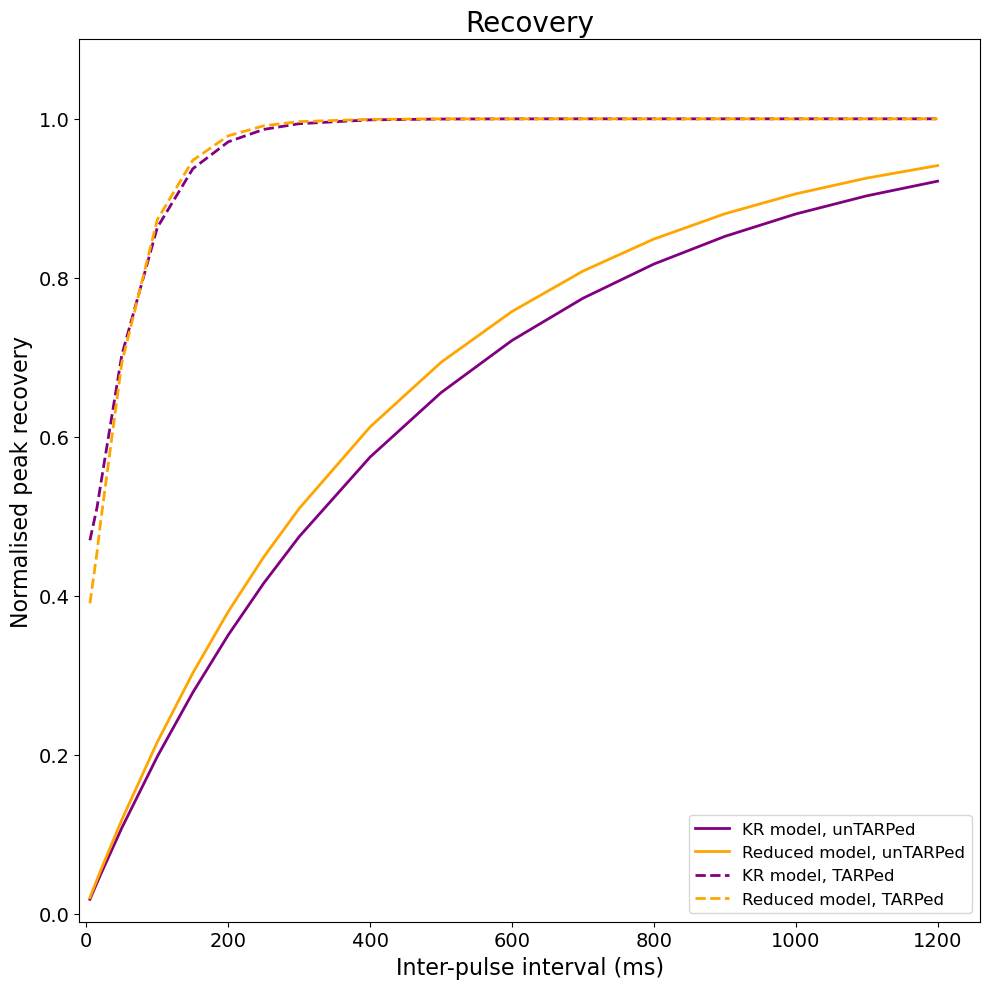

In [11]:


plt.plot(inter, opens2, label='KR model, unTARPed', linestyle='-', color = 'purple')
plt.plot(inter, opens1, label='Reduced model, unTARPed', linestyle='-', color = 'orange')

plt.plot(interT, opens2T, label='KR model, TARPed', linestyle='--', color = 'purple')
plt.plot(interT, opens1T, label='Reduced model, TARPed', linestyle='--', color = 'orange')


# plt.xscale('log')
plt.xlim(-10,)
plt.ylim(-0.01, 1.1)
plt.legend(fontsize=12)
plt.title('Recovery', fontsize=20)
plt.ylabel('Normalised peak recovery', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Inter-pulse interval (ms)', fontsize=16)
plt.tight_layout()
# plt.savefig('Recovery_sample456546.pdf')
plt.show()
plt.close()

# Train stimulation

### TARPless

##### Single pulse

(-0.01, 0.88)

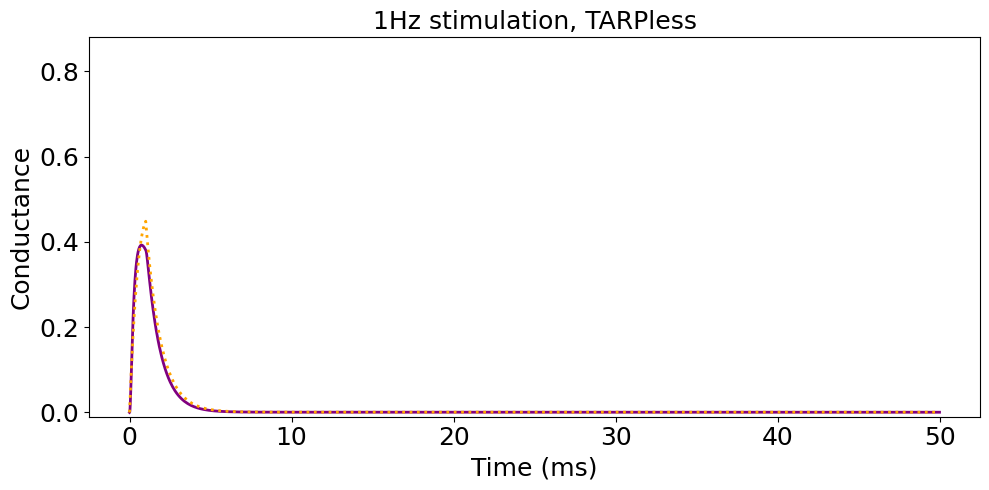

In [118]:
# 1 pulse
alpha=6
solRH = solve_ivp(Milstein2007, [0, 50], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 50], y2, args =  (0, 1, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)


plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)

plt.title('1Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
# plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.xlim(-1, 50)
# plt.ylim(0.0, 0.01)
plt.ylim(-0.01, 0.88)


In [119]:
np.savetxt('Single_pulse_TARPless_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('Single_pulse_TARPless_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('Single_pulse_TARPless_t', solRH.t)

#### 5Hz

(-0.01, 0.88)

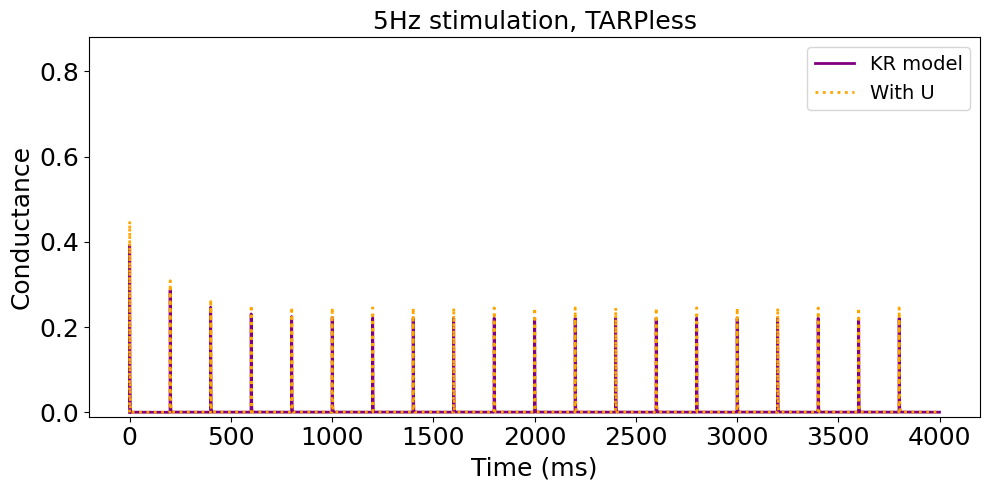

In [120]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 5, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 5, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('5Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
plt.ylim(-0.01, 0.88)


In [121]:
np.savetxt('5Hz_train_TARPless_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('5Hz_train_TARPless_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('5Hz_train_TARPless_t', solRH.t)

#### 10Hz

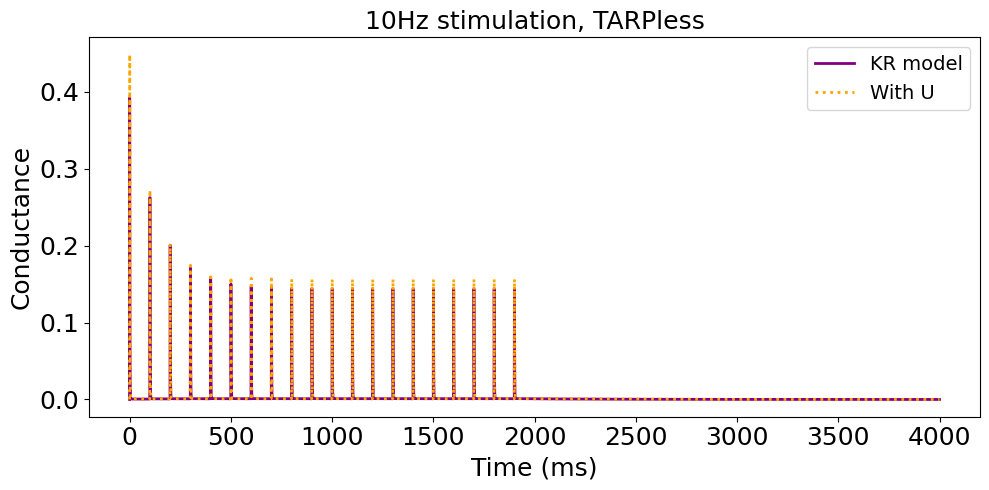

In [122]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 10, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('10Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.ylim(-0.01, 0.88)


In [123]:
np.savetxt('10Hz_train_TARPless_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('10Hz_train_TARPless_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('10Hz_train_TARPless_t', solRH.t)

#### 20Hz

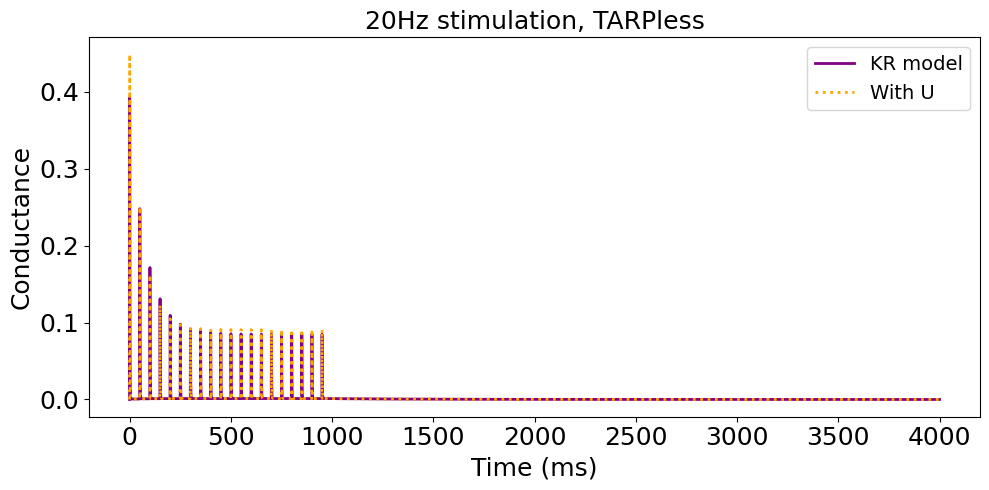

In [124]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 20, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('20Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.ylim(-0.01, 0.88)


In [125]:
np.savetxt('20Hz_train_TARPless_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('20Hz_train_TARPless_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('20Hz_train_TARPless_t', solRH.t)

### TARPed

##### Single pulse

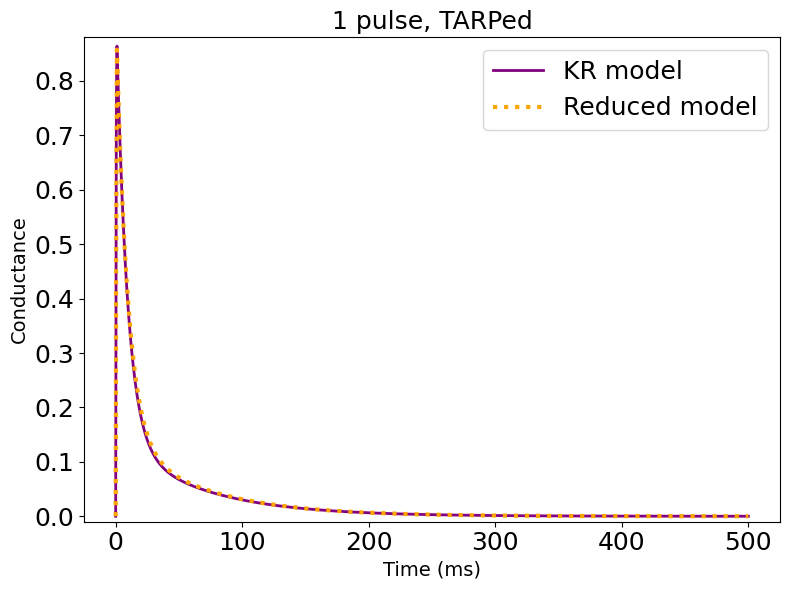

In [126]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 500], y3, args = (0, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 1, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 500], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('1 pulse, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [127]:
np.savetxt('Single_pulse_TARPed_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('Single_pulse_TARPed_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('Single_pulse_TARPed_t', solRH.t)

##### 5Hz

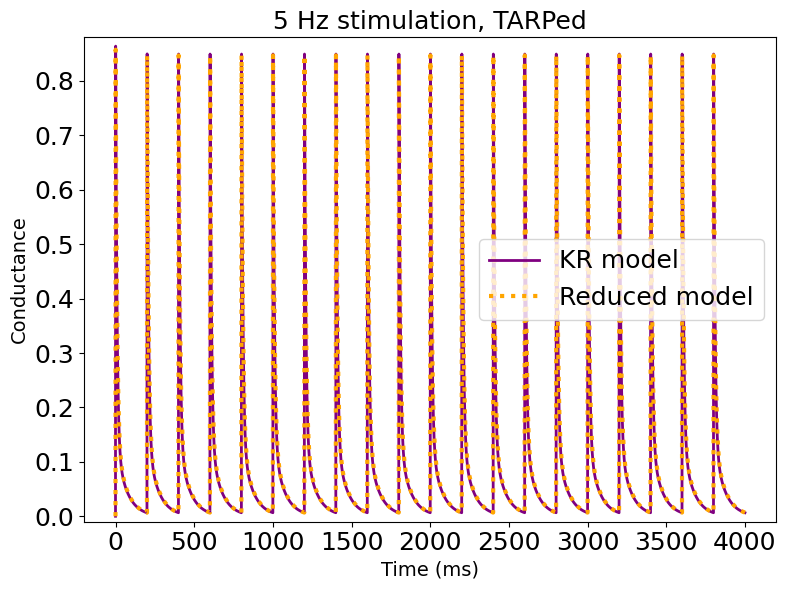

In [128]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 5, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('5 Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [129]:
np.savetxt('5Hz_train_TARPed_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('5Hz_train_TARPed_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('5Hz_train_TARPed_t', solRH.t)

##### 10Hz

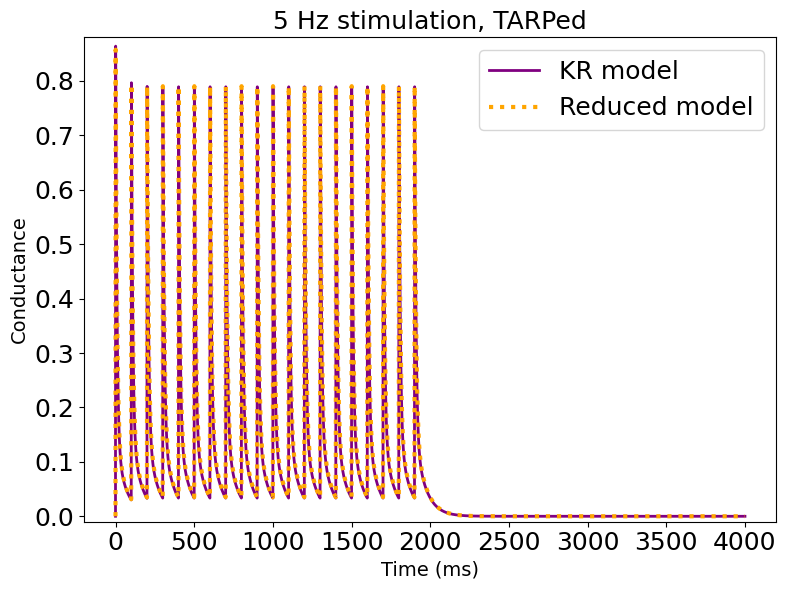

In [130]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 10, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('5 Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [131]:
np.savetxt('10Hz_train_TARPed_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('10Hz_train_TARPed_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('10Hz_train_TARPed_t', solRH.t)

#### 20Hz

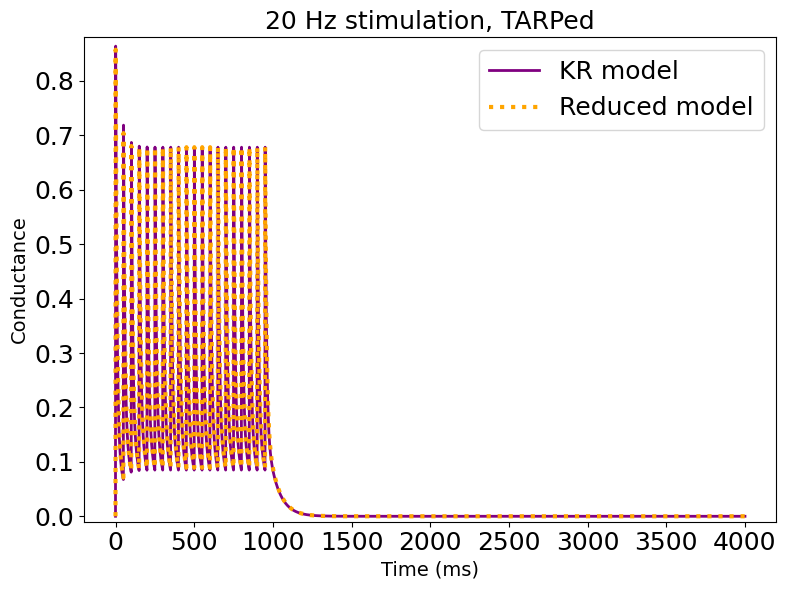

In [132]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 20, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('20 Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [133]:
np.savetxt('20Hz_train_TARPed_KR', solRH.y[2,:] + 2*solRH.y[5,:])
np.savetxt('20Hz_train_TARPed_red', sol_norm4.y[2,:] + sol_norm4.y[3,:])
np.savetxt('20Hz_train_TARPed_t', solRH.t)

# Poisson input

In [10]:
def generate_poisson_timestamps(rate_hz, total_time_ms, seed=None):
    """
    Generates event timestamps (in ms) where ISIs are exponentially distributed.
    
    Parameters:
    - rate_hz: Average firing rate in Hz.
    - total_time_ms: Total duration of the generated spike train in ms.
    - seed: Optional random seed for reproducibility.
    """
    if seed is not None:
        np.random.seed(seed)
        
    mean_isi_ms = 1000.0 / rate_hz
    
    # Estimate upper bound for number of pulses needed
    estimated_n = int((total_time_ms / mean_isi_ms) * 3)
    
    # Generate ISIs and sum them up
    isis = np.random.exponential(scale=mean_isi_ms, size=estimated_n)
    timestamps = np.cumsum(isis)

    
    # Filter out timestamps exceeding total_time_ms
    return timestamps[timestamps <= (total_time_ms)]

In [13]:
t2 = generate_poisson_timestamps(rate_hz=10, total_time_ms=4000, seed=0)
# t2 = t2[:20]

(-0.01, 0.88)

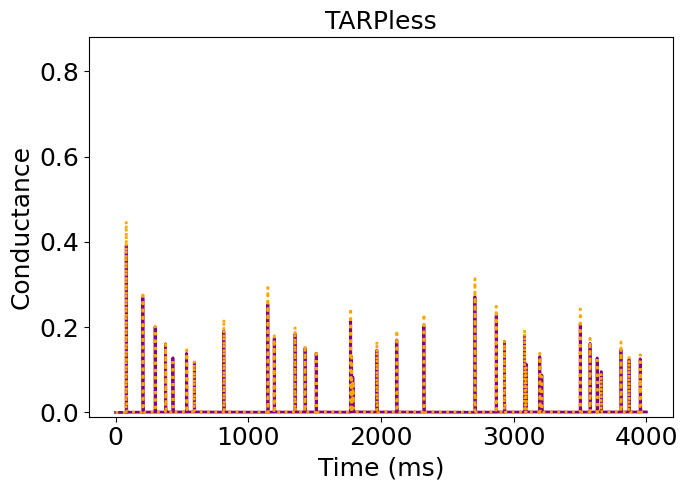

In [18]:
# TARPless

# Reduced model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (4, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, t2, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(7, 5))
plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)

plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
# plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.xlim(-1, 50)
# plt.ylim(0.0, 0.01)
plt.ylim(-0.01, 0.88)

In [31]:
np.savetxt('Poisson_TARPless_KR.txt', solRH.y[2,:] + 2*solRH.y[5,:], delimiter=',')
np.savetxt('Poisson_TARPless_Red.txt', sol_norm4.y[2,:] + sol_norm4.y[3,:], delimiter=',')
np.savetxt('Poisson_TARPless_t.txt', solRH.t[:], delimiter=',')

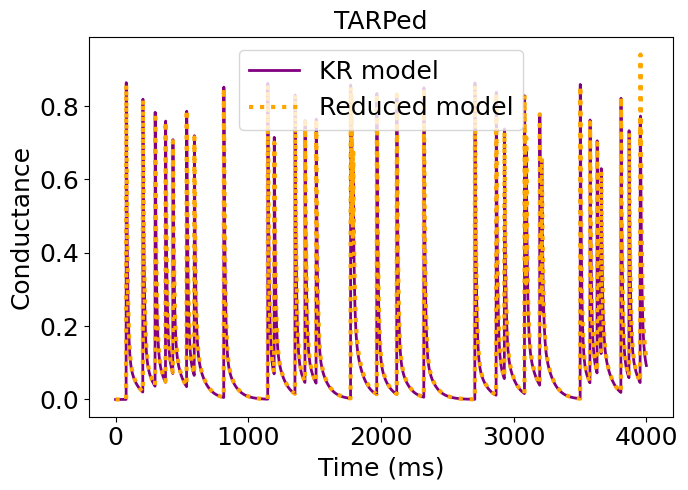

In [19]:
# TARPed

# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (4, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, t2, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]

sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(7, 5))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [33]:
np.savetxt('Poisson_TARPed_KR.txt', solRH.y[2,:] + 2*solRH.y[5,:], delimiter=',')
np.savetxt('Poisson_TARPed_Red.txt', sol_norm4.y[2,:] + sol_norm4.y[3,:], delimiter=',')
np.savetxt('Poisson_TARPed_t.txt', solRH.t[:], delimiter=',')

# Long glutamate pulse

In [12]:
# Reduced model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 150], y3, args = (3, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 100, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 150], y2, args =  (3, 100, tauX, tauU, tauK, taug, A1, A2, alpha, U_0, 1, 1.0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(7, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.title('1Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.close()

print(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]))
print(simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

print('relative error = ', np.abs(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]) - simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:])) / simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

1.9738678519229185
2.1178442839452845
relative error =  0.06798253918562677


In [ ]:
# np.savetxt('100ms_1mM_glu_TARPless_KR.txt', solRH.y[2,:] + 2*solRH.y[5,:], delimiter=',')
# np.savetxt('100ms_1mM_glu_TARPless_Red.txt', sol_norm4.y[2,:] + sol_norm4.y[3,:], delimiter=',')
# np.savetxt('100ms_1mM_glu_TARPless_t.txt', solRH.t[:], delimiter=',')

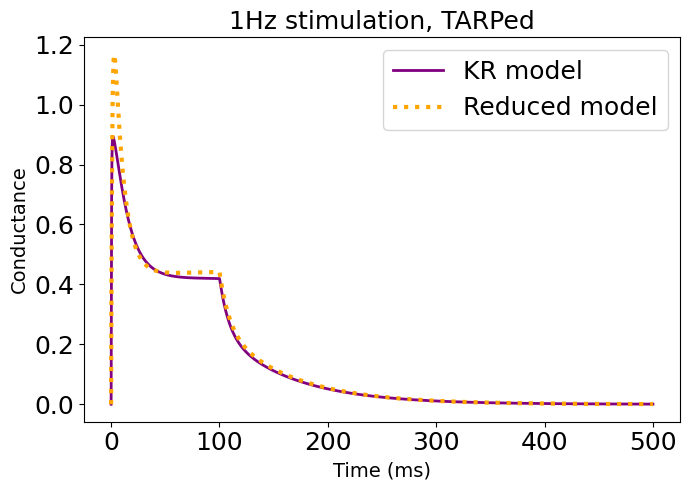

70.25120644510547
66.78222559805559
relative error =  0.05194467264281889


In [9]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 500], y3, args = (3, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 100, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 500], y2, args =  (3, 100, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, 1), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(7, 5))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('1Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()
plt.show()


print(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]))
print(simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

print('relative error = ', np.abs(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]) - simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:])) / simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

In [ ]:
# np.savetxt('100ms_1mM_glu_TARPed_KR.txt', solRH.y[2,:] + 2*solRH.y[5,:], delimiter=',')
# np.savetxt('100ms_1mM_glu_TARPed_Red.txt', sol_norm4.y[2,:] + sol_norm4.y[3,:], delimiter=',')
# np.savetxt('100ms_1mM_glu_TARPed_t.txt', solRH.t[:], delimiter=',')

# Different glutamate pulse

In [ ]:
# 1->2
# 2->3.5
# 3->5
# 4->6
# 5->6.5
# 6->7
# 7->8
# 8->8.5
# 9->9
# 10->10


0.749425219619907
0.6821848846700334
relative error =  853.8225284332708
relative error =  0.0985661460124512


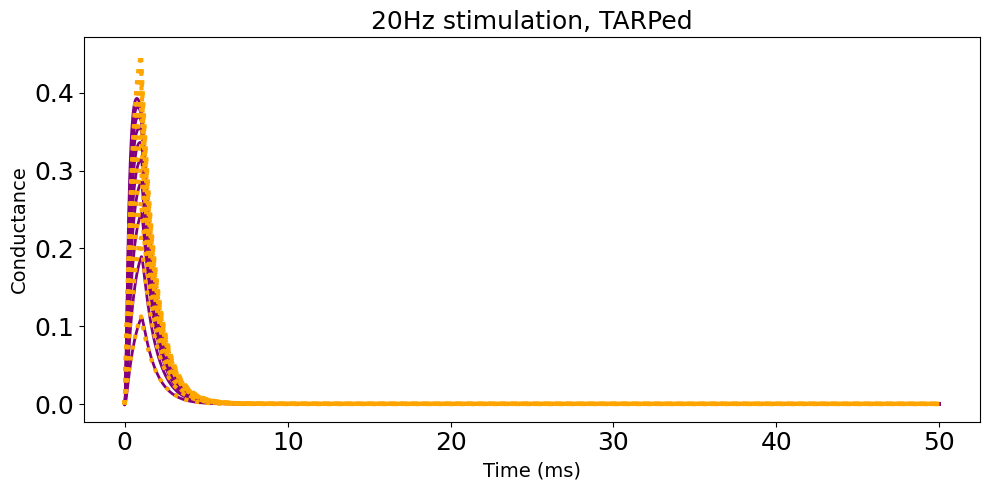

In [ ]:
plt.figure(figsize=(10, 5))

alpha=6
solRH = solve_ivp(Milstein2007, [0, 50], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, 0.01*i), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt('1ms_glu_TARPless_t.txt', solRH.t, delimiter=',')


# KR model
for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    alpha=6
    solRH = solve_ivp(Milstein2007, [0, 50], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, 0.01*i), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2, alpha=1)
    np.savetxt(f'1ms_{i}mM_glu_TARPless_KR.txt', solRH.y[2,:] + 2*solRH.y[5,:], delimiter=',')



# Reduced model
j=1
for i in [2, 4, 5, 6, 7, 8, 8.5, 9, 9.5, 10]:
          
    tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
    taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
    y2=[1, U_0, 0, 0]
    sol_norm4 = solve_ivp(time_2first_ord, [0, 50], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, 0.1*i), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3, alpha=1)
    np.savetxt(f'1ms_{j}mM_glu_TARPless_red.txt', sol_norm4.y[2,:] + sol_norm4.y[3,:])
    j+=1


# plt.legend()
plt.title('20Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18) 

# plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

print(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]))
print(simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

print('relative error = ', np.sum((np.log((sol_norm4.y[2,1:] + sol_norm4.y[3,1:])) - np.log((solRH.y[2,1:] + 2*solRH.y[5,1:])))**2))

print('relative error = ', np.abs(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]) - simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:])) / simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

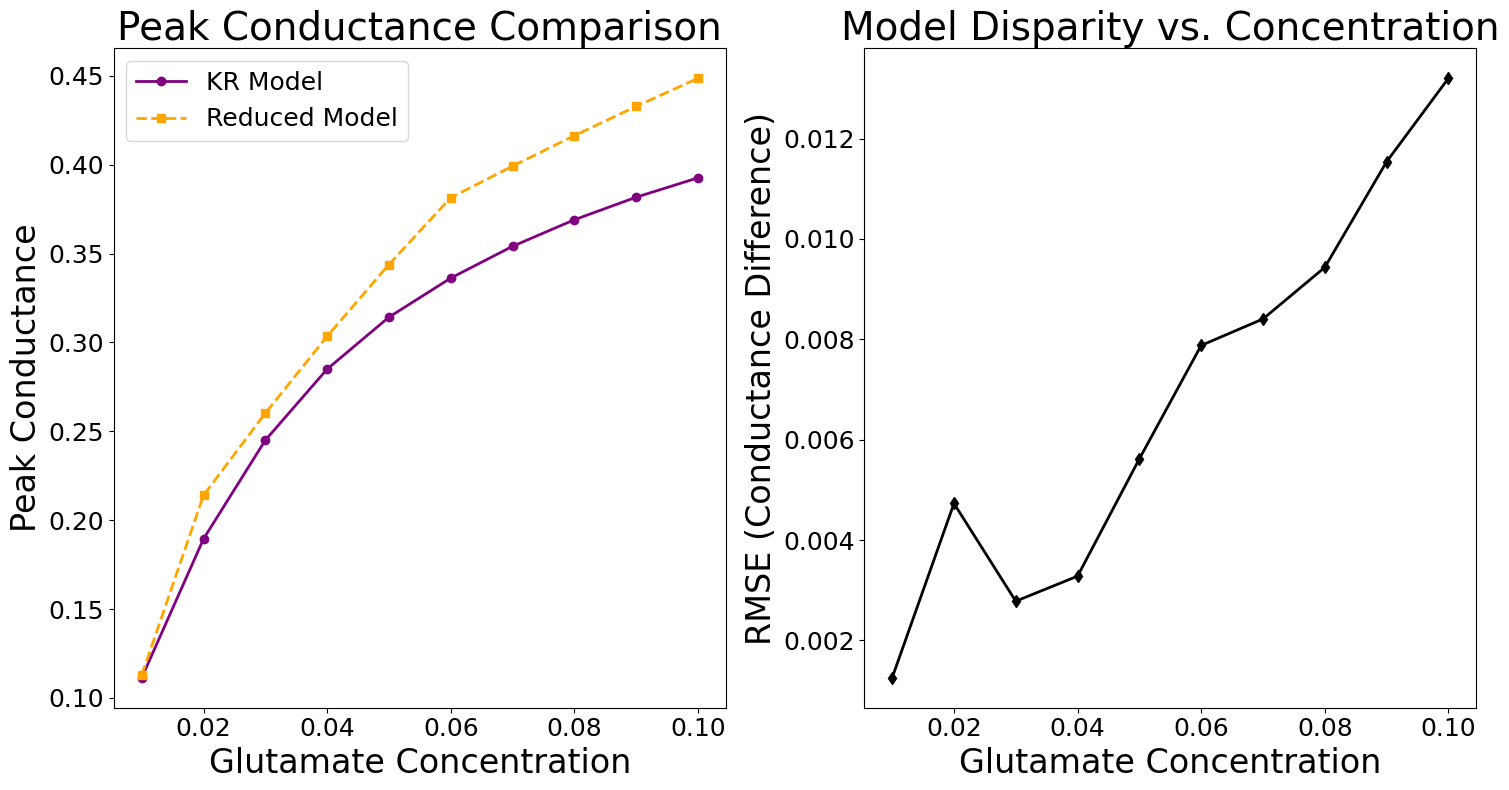

In [ ]:
glutamate_concs = np.array([0.01 * i for i in range(1, 11)])
peak_KR, peak_Red, rmse_list = [], [], []
red_concs = [2, 4, 5, 6, 7, 8, 8.5, 9, 9.5, 10]

tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]

for i, conc in enumerate(glutamate_concs):
    # Solve models
    alpha=6
    solRH = solve_ivp(Milstein2007, [0, 200], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, conc), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
    g_KR = solRH.y[2] + 2*solRH.y[5]
    
    alpha=1
    sol_norm4 = solve_ivp(time_2first_ord, [0, 200], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, red_concs[i]/10), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    g_Red = sol_norm4.y[2, :] + sol_norm4.y[3, :]

    # Calculate metrics
    peak_KR.append(np.max(g_KR))
    peak_Red.append(np.max(g_Red))
    rmse_list.append(np.sqrt(np.mean((g_KR - g_Red) ** 2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Plot 1: Peak Conductance comparison
ax1.plot(glutamate_concs, peak_KR, 'o-', color='purple', label='KR Model')
ax1.plot(glutamate_concs, peak_Red, 's--', color='orange', label='Reduced Model')
ax1.set_xlabel('Glutamate Concentration')
ax1.set_ylabel('Peak Conductance')
ax1.set_title('Peak Conductance Comparison')
ax1.legend()

# Plot 2: Direct model disparity (RMSE)
ax2.plot(glutamate_concs, rmse_list, 'd-', color='black')
ax2.set_xlabel('Glutamate Concentration')
ax2.set_ylabel('RMSE (Conductance Difference)')
ax2.set_title('Model Disparity vs. Concentration')

plt.tight_layout()
plt.show()

In [ ]:
# 1->2
# 2->4
# 3->5
# 4->6
# 5->7
# 6->8
# 7->8.5
# 8->9
# 9->9.5
# 10->10

16.31324336487757
15.858058765481614
relative error =  0.028703677173070034


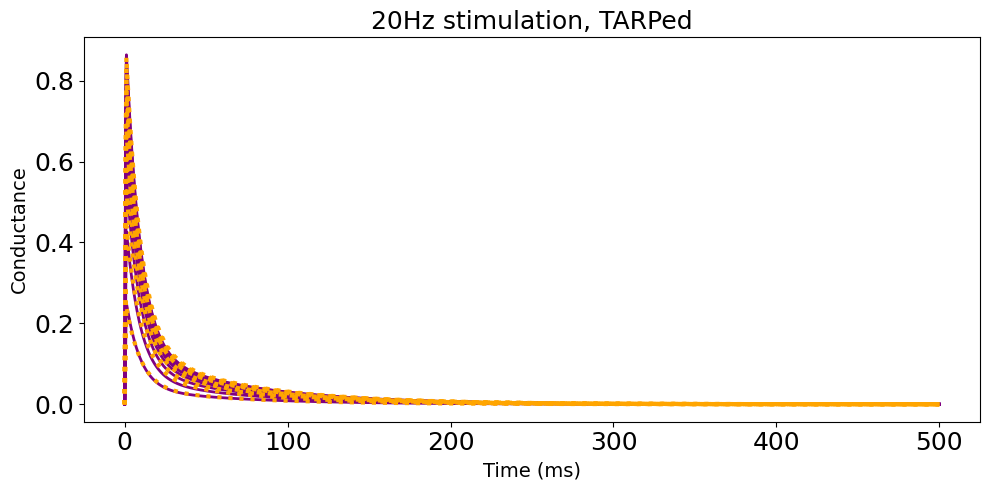

In [ ]:
plt.figure(figsize=(10, 5))

alpha=6
solRH = solve_ivp(Milstein2007, [0, 500], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, 0.01*i), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt('1ms_glu_TARPed_t.txt', solRH.t, delimiter=',')


# KR model
for i in range(1,11):
    alpha=6
    solRH = solve_ivp(Milstein2007, [0, 500], y3, args = (0, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 1, 1.1, 0.3, 0.01*i), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
    np.savetxt(f'1ms_{i}mM_glu_TARPed_KR.txt', solRH.y[2,:] + 2*solRH.y[5,:], delimiter=',')


j=1
# Reduced model
for i in [2, 4, 5, 6, 7, 8, 8.5, 9, 9.5, 10]:
    tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
    taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
    y2 = [1, U_0 ,0 ,0]
    sol_norm4 = solve_ivp(time_2first_ord, [0, 500], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, 0.1*i), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    plt.plot(sol_norm4.t, sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)
    np.savetxt(f'1ms_{j}mM_glu_TARPed_red.txt', sol_norm4.y[2,:] + sol_norm4.y[3,:])
    j+=1



# plt.legend()
plt.title('20Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18) 

# plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

print(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]))
print(simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

print('relative error = ', np.abs(simpson(sol_norm4.y[2,2:] + sol_norm4.y[3,2:], sol_norm4.t[2:]) - simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:])) / simpson(solRH.y[2,2:] + 2*solRH.y[5,2:], solRH.t[2:]))

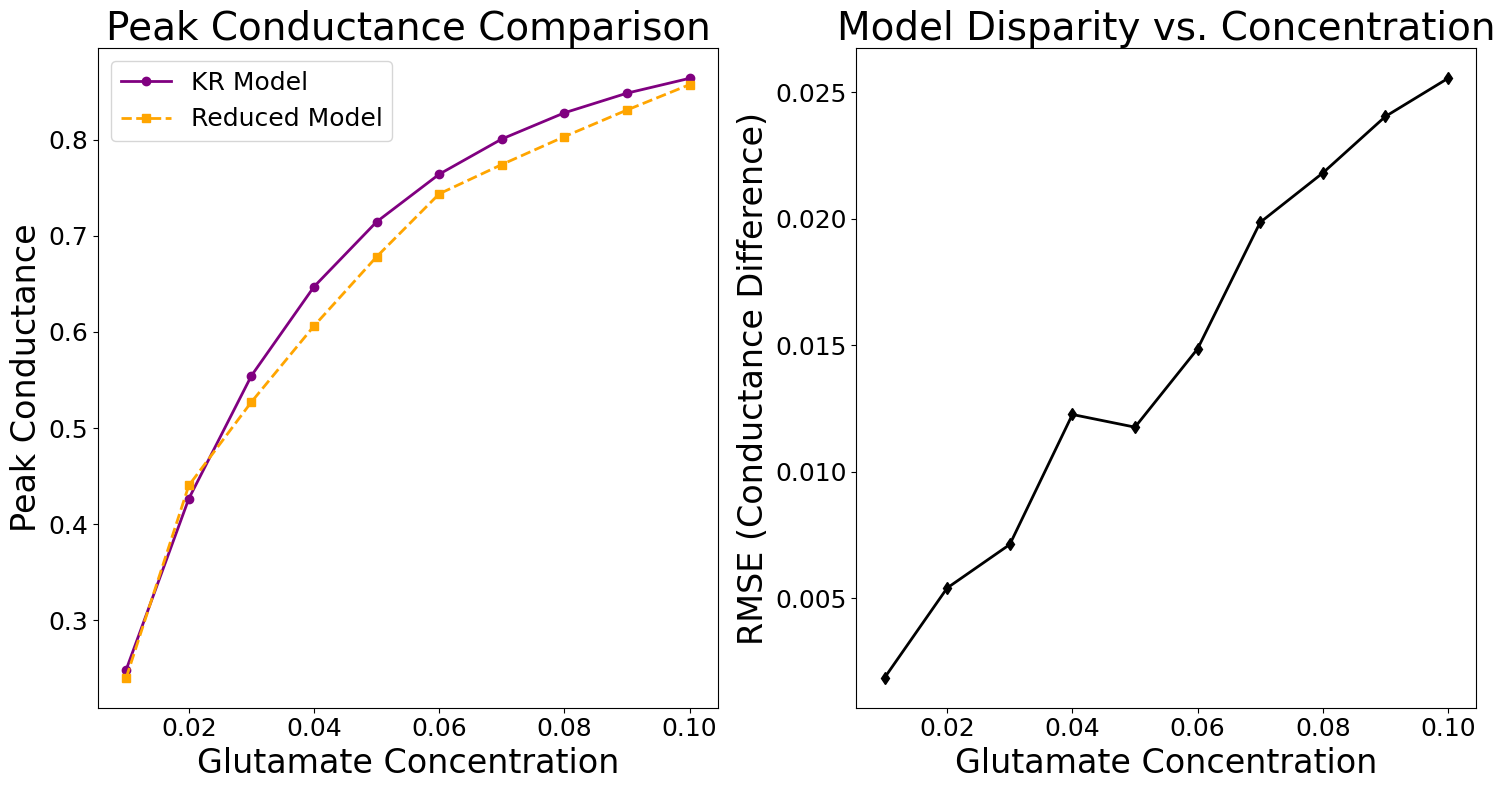

In [ ]:
glutamate_concs = np.array([0.01 * i for i in range(1, 11)])
peak_KR, peak_Red, rmse_list = [], [], []
red_concs = [2, 4, 5, 6, 7, 8, 8.5, 9, 9.5, 10]

tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]

for i, conc in enumerate(glutamate_concs):
    # Solve models
    alpha=6
    solRH = solve_ivp(Milstein2007, [0, 200], y3, args = (0, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 1, 1.1, 0.3, conc), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
    g_KR = solRH.y[2] + 2*solRH.y[5]
    
    alpha=1
    sol_norm4 = solve_ivp(time_2first_ord, [0, 200], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, red_concs[i]/10), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
    g_Red = sol_norm4.y[2, :] + sol_norm4.y[3, :]

    # Calculate metrics
    peak_KR.append(np.max(g_KR))
    peak_Red.append(np.max(g_Red))
    rmse_list.append(np.sqrt(np.mean((g_KR - g_Red) ** 2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Plot 1: Peak Conductance comparison
ax1.plot(glutamate_concs, peak_KR, 'o-', color='purple', label='KR Model')
ax1.plot(glutamate_concs, peak_Red, 's--', color='orange', label='Reduced Model')
ax1.set_xlabel('Glutamate Concentration')
ax1.set_ylabel('Peak Conductance')
ax1.set_title('Peak Conductance Comparison')
ax1.legend()

# Plot 2: Direct model disparity (RMSE)
ax2.plot(glutamate_concs, rmse_list, 'd-', color='black')
ax2.set_xlabel('Glutamate Concentration')
ax2.set_ylabel('RMSE (Conductance Difference)')
ax2.set_title('Model Disparity vs. Concentration')

plt.tight_layout()
plt.show()

# Overlaying all parameter sets

### Varying first few parameters

In [34]:
data1 = np.load(f'C:/Users/brian/AMPA-Project/Data/opt_params_penalty_unTARPed_Kg_alph1_U0_avfreq1.npy', allow_pickle=True)
dataT1 = np.load(f'C:/Users/brian/AMPA-Project/Data/opt_params_penalty_TARPed_Kg_alph1_U0_avfreq1.npy', allow_pickle=True)

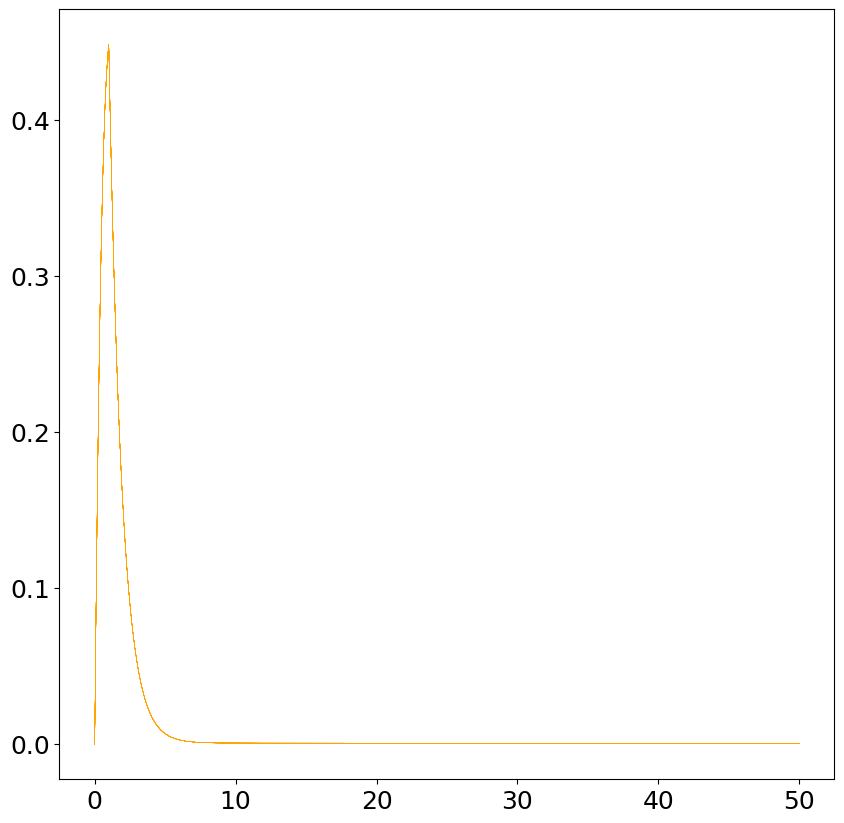

In [35]:
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]

sol_normU = solve_ivp(time_2first_ord, [0, 50], y2, args =  (0, 1, taux, tauu, data1[0,0], data1[0,1], data1[0,2], data1[0,3], 1, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_TARPless_fsA1A2_t.txt', sol_normU.t, delimiter=',')


j=0


for i in data1:
	sol_normU = solve_ivp(time_2first_ord, [0, 50], y2, args =  (0, 1, taux, tauu, i[0], i[1], i[2], i[3], 1, U_0), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPless', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_TARPless_fsA1A2_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1

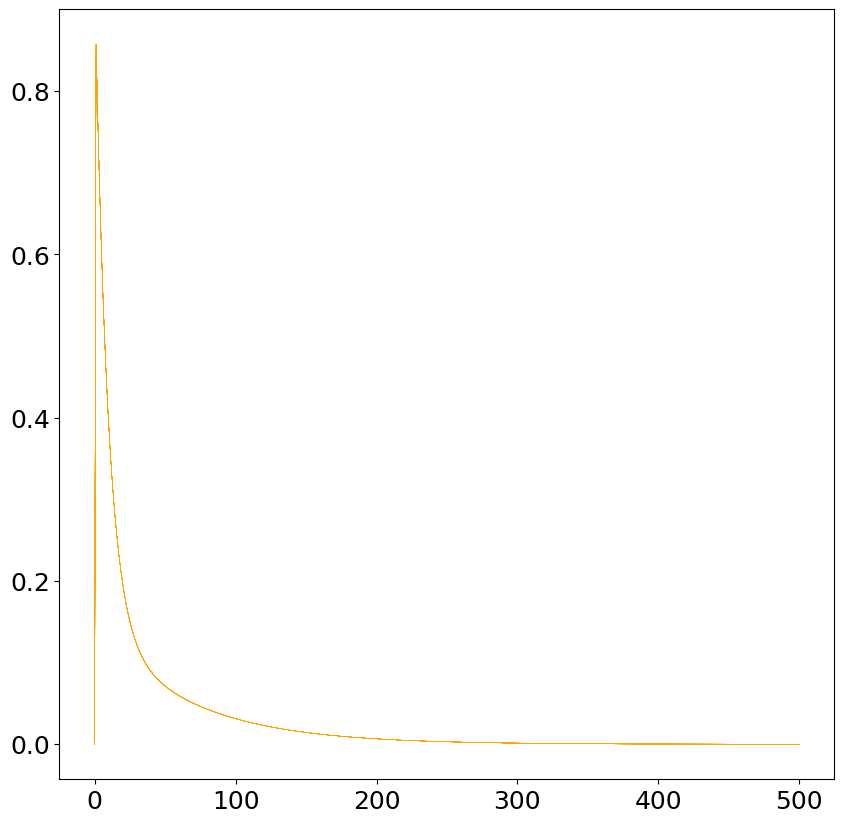

In [36]:
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_normU = solve_ivp(time_2first_ord, [0, 500], y2, args =  (0, 1, taux, tauu, dataT1[0,0], dataT1[0,1], dataT1[0,2], dataT1[0,3], 1, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_TARPed_fsA1A2_t.txt', sol_normU.t, delimiter=',')


j=0


for i in dataT1:
	sol_normU = solve_ivp(time_2first_ord, [0, 500], y2, args =  (0, 1, taux, tauu, i[0], i[1], i[2], i[3], 1, U_0), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPless', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_TARPed_fsA1A2_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1

### Varying other params

In [37]:
data1 = np.load('C:/Users/brian/AMPA-Project/Data/Opt_params_unTARPed_XU_U0var_mixedfreq.npy')
dataT1 = np.load('C:/Users/brian/AMPA-Project/Data/Opt_params_TARPed_XU_U0var_mixedfreq.npy')

#### TARPless

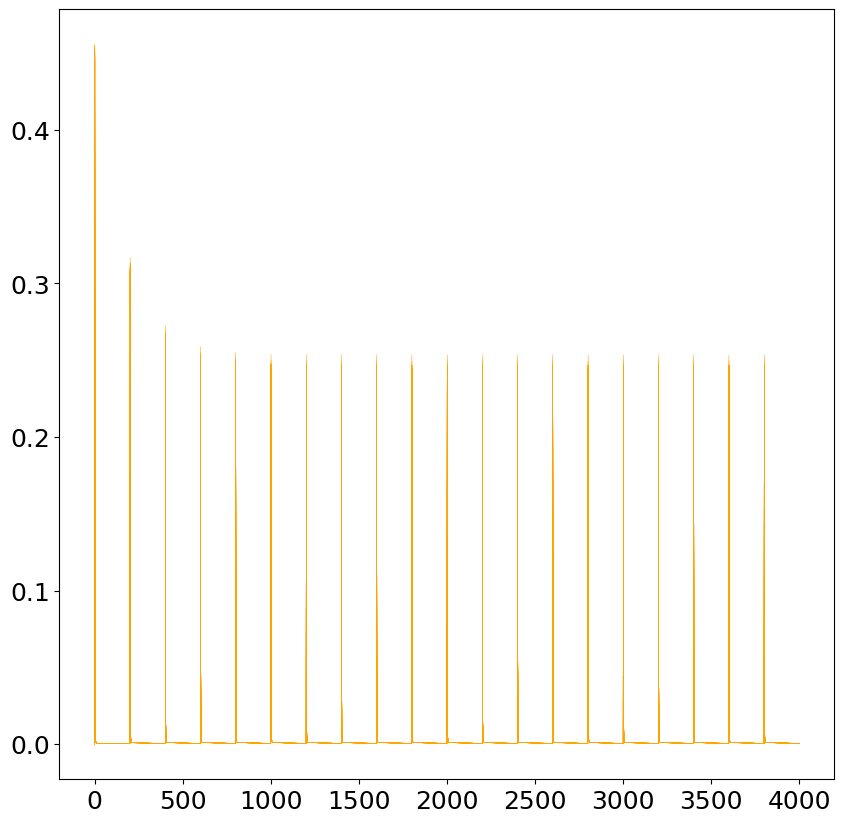

In [38]:
# 5Hz

tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
y2=[1, 0.62727836, 0, 0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 5, data1[0,0], data1[0,1], tauK, taug, A1, A2, 1, data1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_5Hz_TARPless_XUU0_t.txt', sol_normU.t, delimiter=',')

j=0

for i in data1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 5, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPless', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_5Hz_TARPless_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1



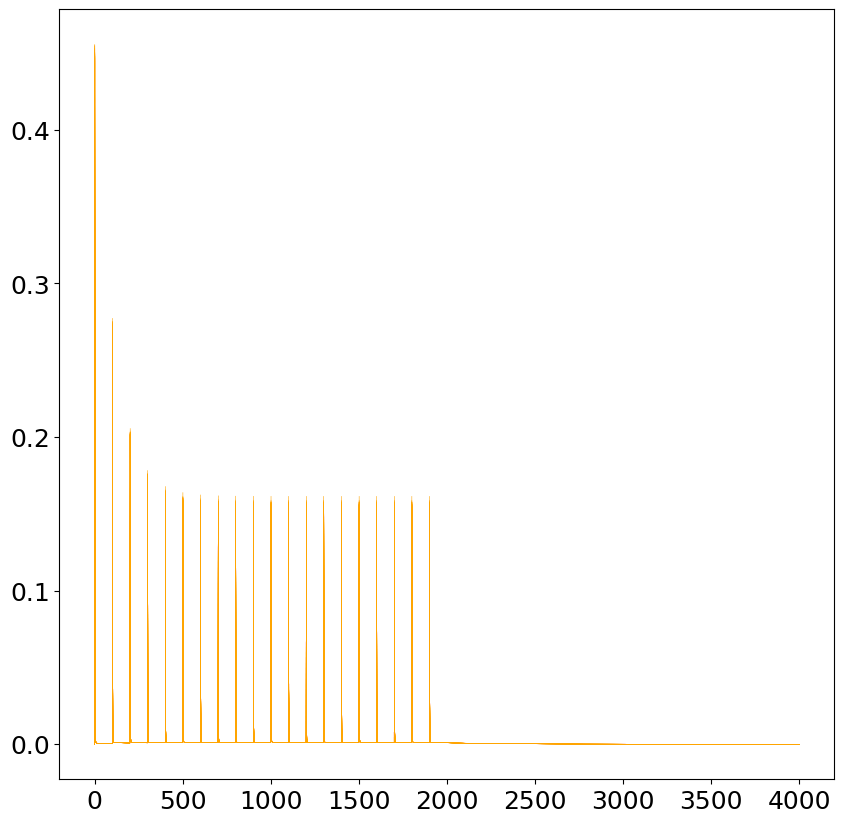

In [39]:
# 10Hz

tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
y2=[1, 0.62727836, 0, 0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, data1[0,0], data1[0,1], tauK, taug, A1, A2, 1, data1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_10Hz_TARPless_XUU0_t.txt', sol_normU.t, delimiter=',')

j=0

for i in data1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPless', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_10Hz_TARPless_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1



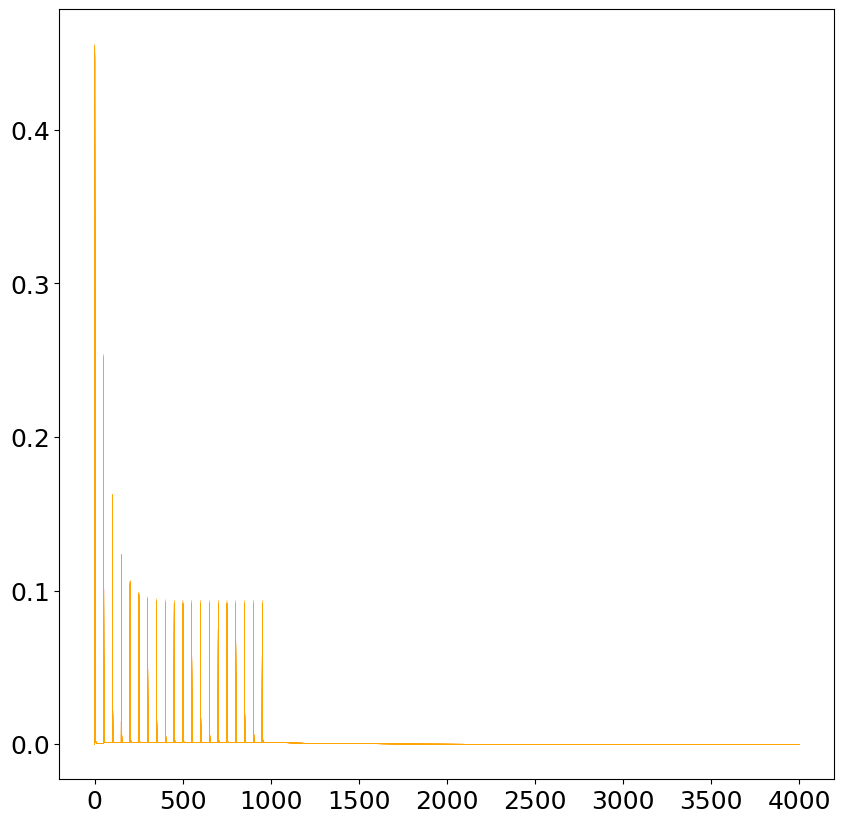

In [40]:
# 20Hz

tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
y2=[1, 0.62727836, 0, 0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, data1[0,0], data1[0,1], tauK, taug, A1, A2, 1, data1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_20Hz_TARPless_XUU0_t.txt', sol_normU.t, delimiter=',')

j=0

for i in data1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPless', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_20Hz_TARPless_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1



#### TARPed

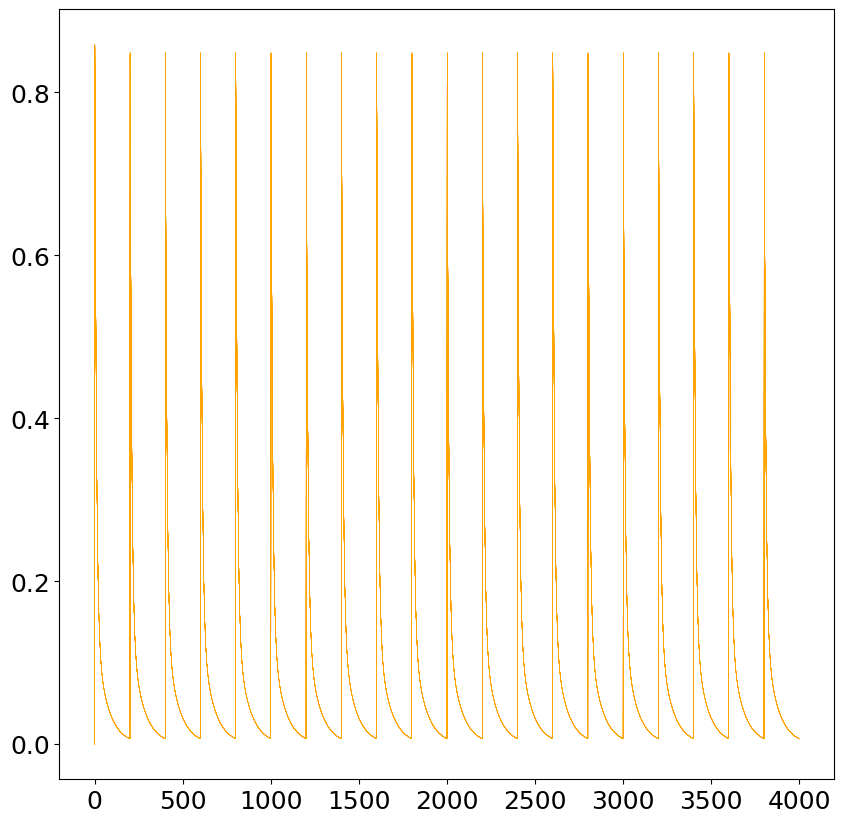

In [41]:
# 5Hz

tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
y2 = [1, 00.9377337949271534, 0 ,0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 5, dataT1[0,0], dataT1[0,1], tauK, taug, A1, A2, 1, dataT1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_5Hz_TARPed_XUU0_t.txt', sol_normU.t, delimiter=',')


j=0

for i in dataT1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 5, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPedd', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_5Hz_TARPed_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1

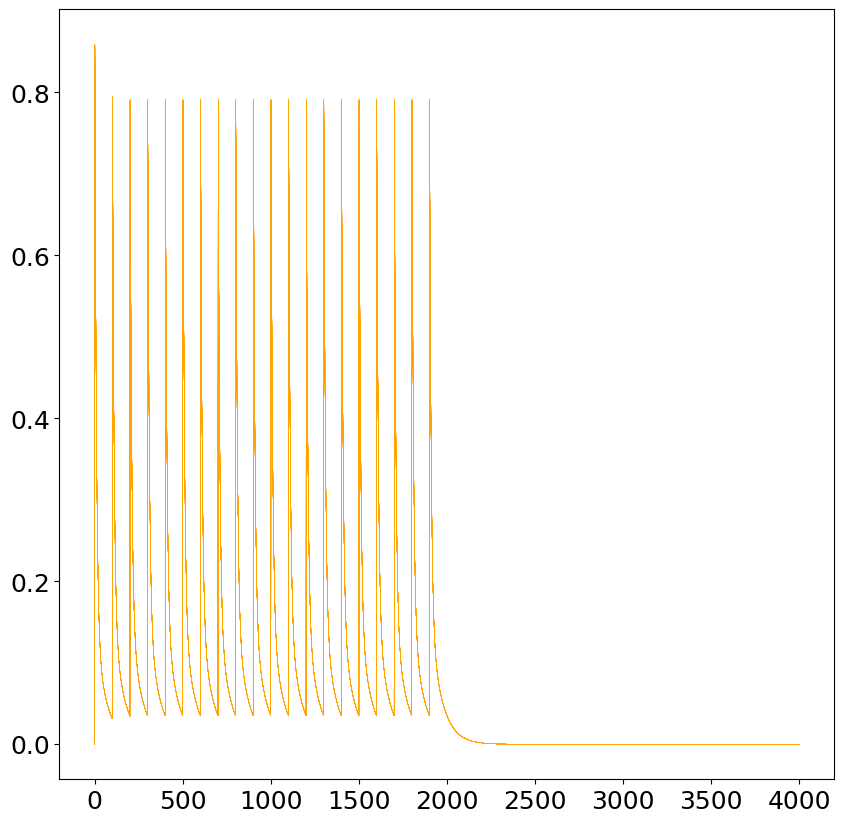

In [42]:
# 10Hz

tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
y2 = [1, 0.9377337949271534, 0 ,0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, dataT1[0,0], dataT1[0,1], tauK, taug, A1, A2, 1, dataT1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_10Hz_TARPed_XUU0_t.txt', sol_normU.t, delimiter=',')


j=0

for i in dataT1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPedd', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_10Hz_TARPed_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1

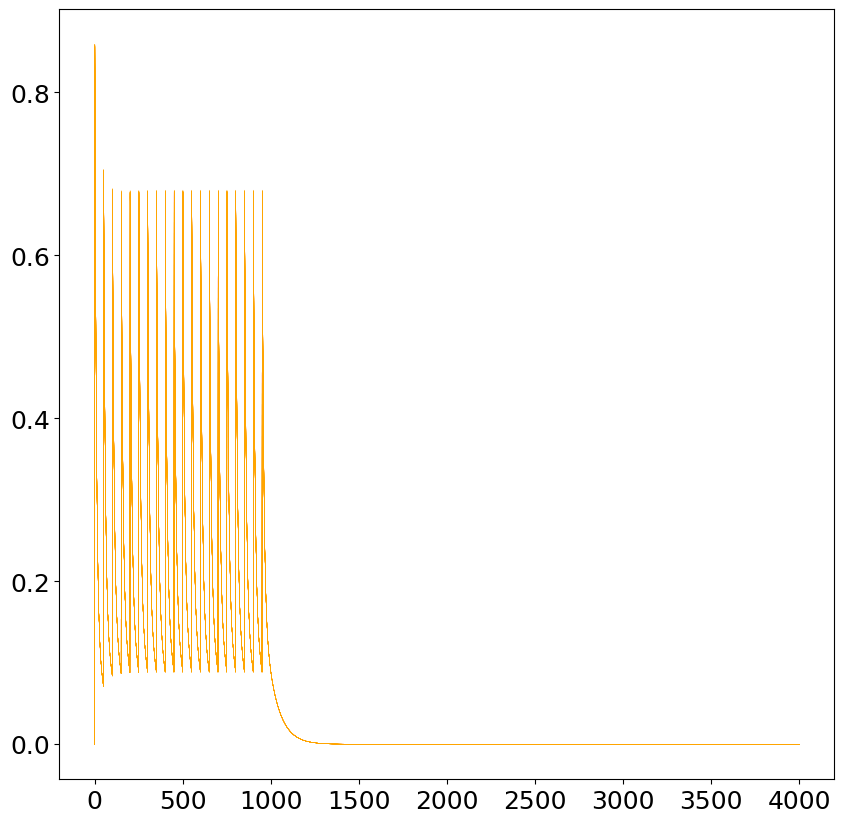

In [43]:
# 20Hz

tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
y2 = [1, 0.9377337949271534, 0 ,0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, dataT1[0,0], dataT1[0,1], tauK, taug, A1, A2, 1, dataT1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_20Hz_TARPed_XUU0_t.txt', sol_normU.t, delimiter=',')


j=0

for i in dataT1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPedd', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_20Hz_TARPed_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1

#### Poisson

In [44]:
data1 = np.load('C:/Users/brian/AMPA-Project/Data/Opt_params_unTARPed_XU_U0var_mixedfreq.npy')
dataT1 = np.load('C:/Users/brian/AMPA-Project/Data/Opt_params_TARPed_XU_U0var_mixedfreq.npy')

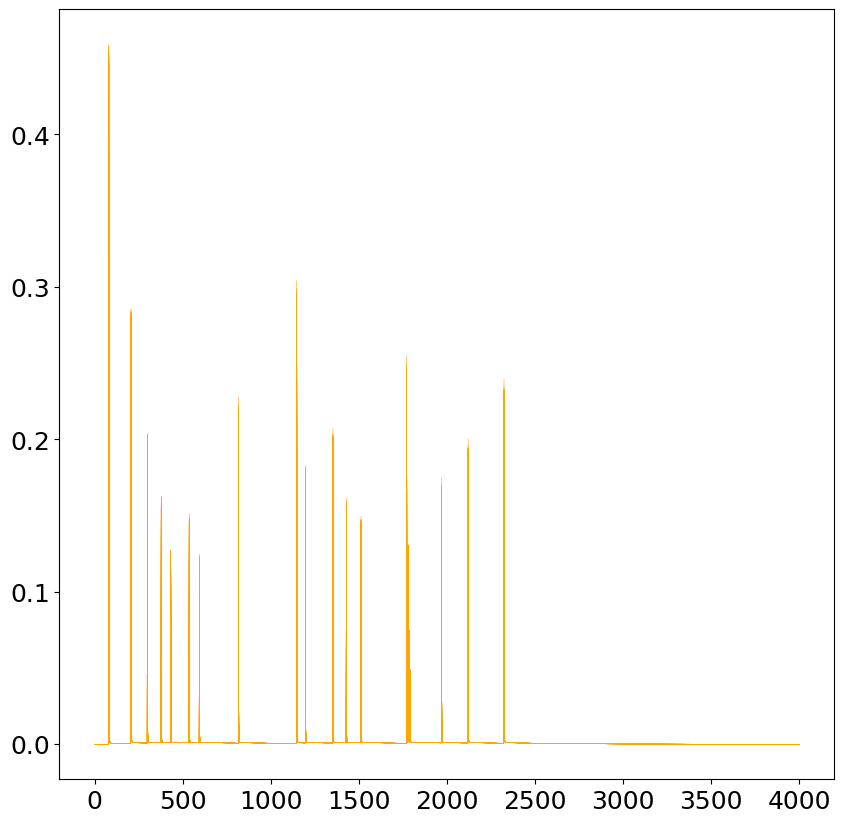

In [45]:
# 5Hz

tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
y2=[1, 0.62727836, 0, 0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, data1[0,0], data1[0,1], tauK, taug, A1, A2, 1, data1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_poisson_TARPless_XUU0_t.txt', sol_normU.t, delimiter=',')

j=0

for i in data1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPless', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_poisson_TARPless_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1



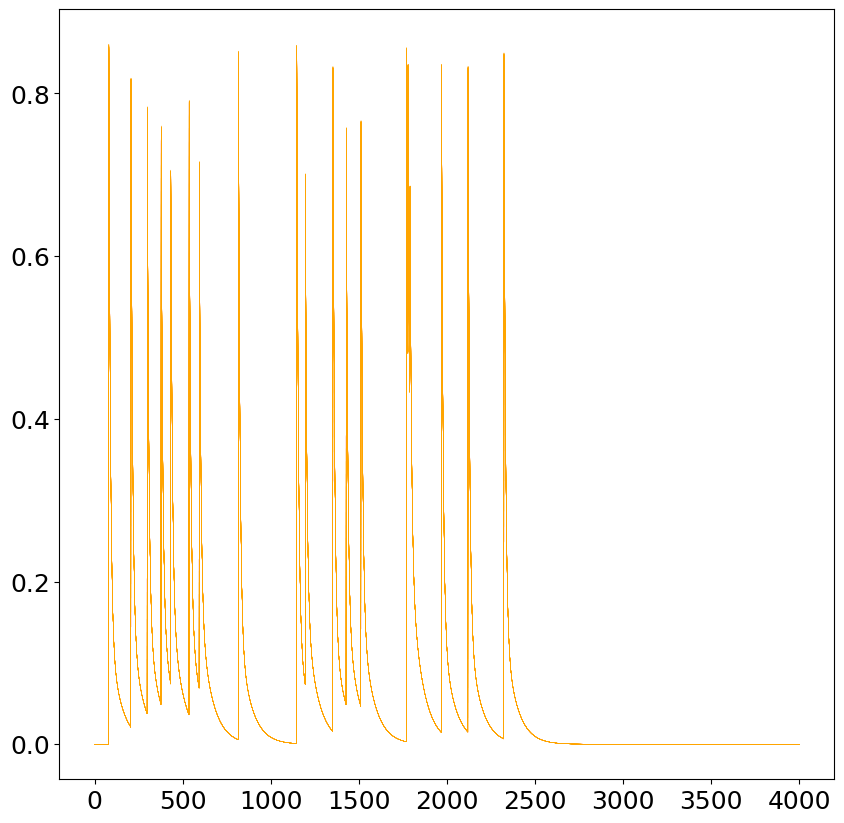

In [46]:
# 5Hz

tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
y2 = [1, 0.9377337949271534, 0 ,0]

sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, dataT1[0,0], dataT1[0,1], tauK, taug, A1, A2, 1, dataT1[0,2]), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_poisson_TARPed_XUU0_t.txt', sol_normU.t, delimiter=',')


j=0

for i in dataT1:
	sol_normU = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, i[0], i[1], tauK, taug, A1, A2, 1, i[2]), dense_output=True, t_eval=sol_normU.t, rtol=1e-8, method='LSODA', max_step=0.1)
	plt.plot(sol_normU.t[:], (sol_normU.y[2,:] + sol_normU.y[3,:]), label='TARPedd', linestyle='-', color='orange', linewidth=0.2)
	np.savetxt(f'C:/Users/brian/AMPA-Project/Data/param_sets_poisson_TARPed_XUU0_{j}.txt', (sol_normU.y[2,:] + sol_normU.y[3,:]), delimiter=',')
	j+=1

# Errors

In [17]:
from sklearn.metrics import r2_score

### Single pulse TARPless

(-0.01, 0.88)

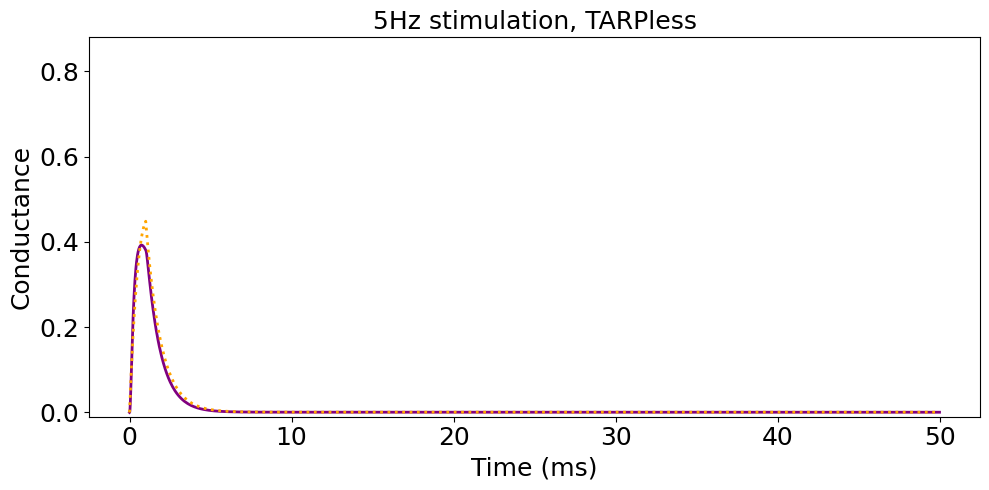

In [123]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 50], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
# solRH = solve_ivp(Milstein2007, [0, 50], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.01)



# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 50], y2, args =  (0, 1, tauX, tauU, tauK, taug, A1, A2, alpha, U_0, 1, 1), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
#
plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('5Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
# plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.xlim(-1, 50)
# plt.ylim(0.0, 0.01)
plt.ylim(-0.01, 0.88)

In [124]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [125]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print(area)
print(area_RH)
print('relative error = ', np.abs((area_RH-area)/area_RH))

0.7494252224643128
0.6821848846700543
relative error =  0.09856615018196994


In [126]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.14260667781607697


In [127]:
# RMSE

print('RMSE = ', np.sqrt(np.mean((KR - red) ** 2)))


RMSE =  0.023261466399760063


In [128]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.9725575300081816


In [122]:
# 90 - 10% decay time

for i in range (1,len(KR)-1):
	if KR[i-1] > 0.9 * np.max(KR) > KR[i]:
		t90KR = solRH.t[i]
	if KR[i-1] > 0.1 * np.max(KR) > KR[i]:
		t10KR = solRH.t[i]

for i in range (1,len(red)-1):
	if red[i-1] > 0.9 * np.max(red) > red[i]:
		t90red = solRH.t[i]
	if red[i-1] > 0.1 * np.max(red) > red[i]:
		t10red = solRH.t[i]


print('90-10% decay time KR = ', t10KR-t90KR)
print('90-10% decay time red = ', t10red-t90red)

print('relative difference = ', np.abs((t10KR-t90KR)-(t10red-t90red))/(t10KR-t90KR))


90-10% decay time KR =  1.9190947742746076
90-10% decay time red =  2.0575511713325647
relative difference =  0.07214672194096916


### 5Hz TARPless

(-0.01, 0.88)

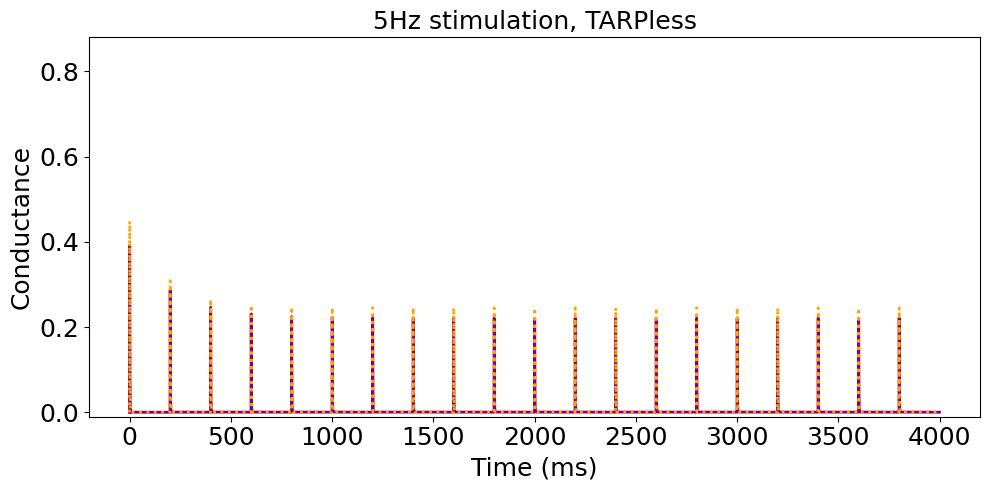

In [55]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 5, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (0, 5, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('5Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
# plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.xlim(-1, 50)
# plt.ylim(0.0, 0.01)
plt.ylim(-0.01, 0.88)

In [56]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [57]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print(area)
print(area_RH)
print('relative error = ', np.abs((area_RH-area)/area_RH))

11.538730667633558
10.835994540051471
relative error =  0.0648520193494624


In [58]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.10540337385923657


In [59]:
# RMSE

np.sqrt(np.mean((KR - red) ** 2))


0.006766494176928056

In [60]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.9839756806486938


### 10Hz TARPless

(-0.01, 0.88)

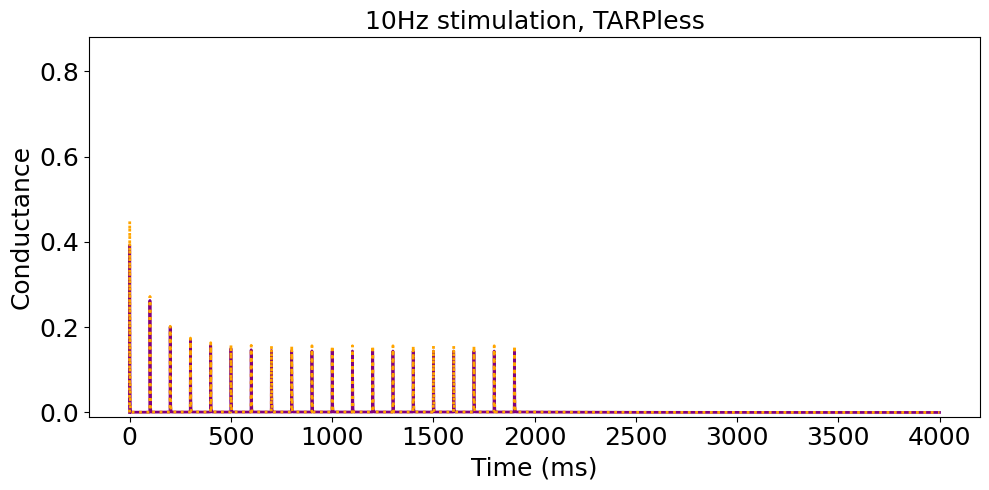

In [61]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 10, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('10Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
# plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.xlim(-1, 50)
# plt.ylim(0.0, 0.01)
plt.ylim(-0.01, 0.88)


In [62]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [63]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print(area)
print(area_RH)
print('relative error = ', np.abs((area_RH-area)/area_RH))

8.16416569794059
7.917335965487593
relative error =  0.03117585681963603


In [64]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.07405934658435921


In [65]:
# RMSE

np.sqrt(np.mean((KR - red) ** 2))


0.004902510163910072

In [66]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.9849409626987256


### 20Hz TARPless

(-0.01, 0.88)

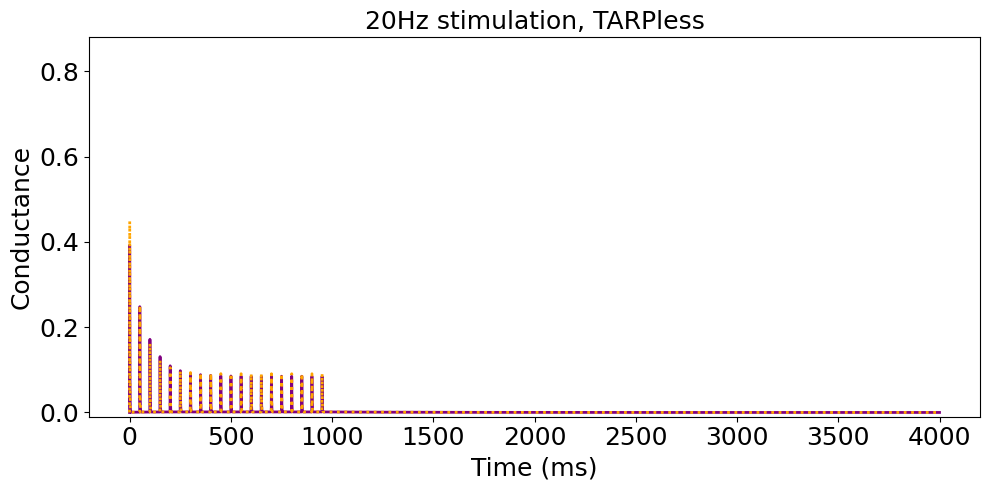

In [67]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 20, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)

plt.figure(figsize=(10, 5))

plt.plot(solRH.t[:], solRH.y[2,:] + 2*solRH.y[5,:], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='With U', linestyle=':', color='orange', linewidth=2)


plt.title('20Hz stimulation, TARPless', fontsize=18)
plt.xlabel('Time (ms)', fontsize=18)
plt.ylabel('Conductance', fontsize=18)
# plt.legend(fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.tight_layout()
# plt.xlim(-1, 50)
# plt.ylim(0.0, 0.01)
plt.ylim(-0.01, 0.88)


In [68]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [69]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print(area)
print(area_RH)
print('relative error = ', np.abs((area_RH-area)/area_RH))

5.54197297008532
5.539358736112687
relative error =  0.0004719380161443179


In [70]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.05838261936769483


In [71]:
# RMSE

np.sqrt(np.mean((KR - red) ** 2))


0.004158033549277311

In [72]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.9824857298589643


### Single pulse TARPed

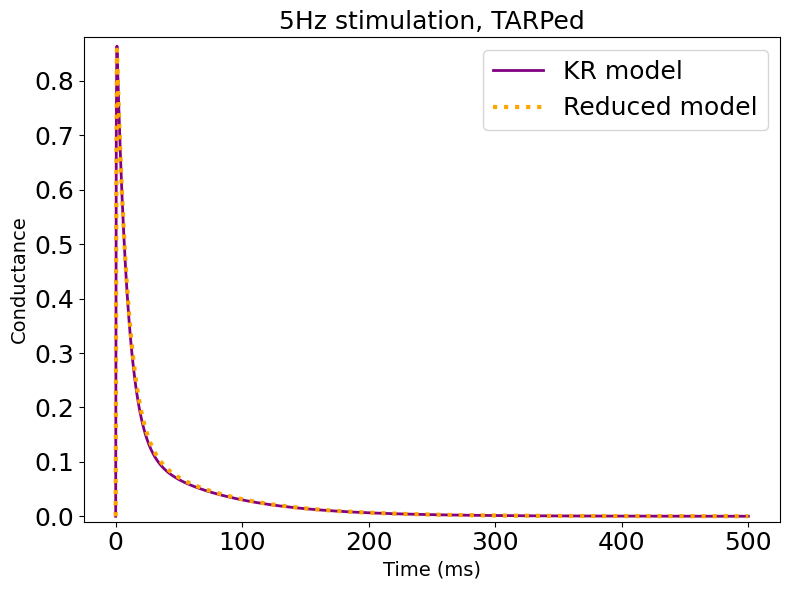

In [73]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 500], y3, args = (0, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 1, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 500], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('5Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [74]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [75]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print(area)
print(area_RH)
print('relative error = ', np.abs((area_RH-area)/area_RH))

16.313243336765833
15.858058549963953
relative error =  0.028703689380874076


In [76]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.007578512716695132


In [77]:
# RMSE

np.sqrt(np.mean((KR - red) ** 2))


0.016554857843061807

In [78]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.9871919550488868


In [79]:
# 90 - 10% decay time

for i in range (1,len(KR)-1):
	if KR[i-1] > 0.9 * np.max(KR) > KR[i]:
		t90KR = solRH.t[i]
	if KR[i-1] > 0.1 * np.max(KR) > KR[i]:
		t10KR = solRH.t[i]

for i in range (1,len(red)-1):
	if red[i-1] > 0.9 * np.max(red) > red[i]:
		t90red = solRH.t[i]
	if red[i-1] > 0.1 * np.max(red) > red[i]:
		t10red = solRH.t[i]


print('90-10% decay time KR = ', t10KR-t90KR)
print('90-10% decay time red = ', t10red-t90red)

print('relative difference = ', np.abs((t10KR-t90KR)-(t10red-t90red))/(t10KR-t90KR))


90-10% decay time KR =  36.60000000000028
90-10% decay time red =  39.40000000000032
relative difference =  0.07650273224043766


### 5Hz TARPed

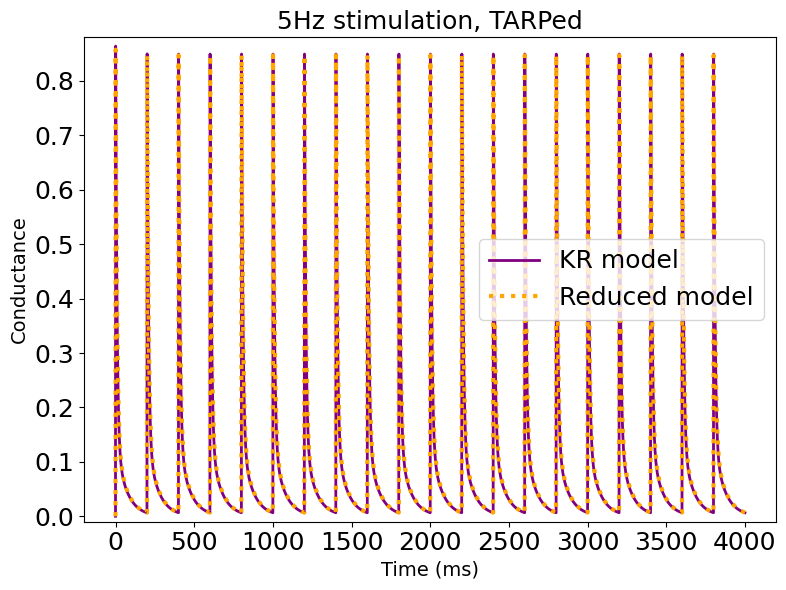

In [80]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (0, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 5, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (0, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('5Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [81]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [82]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print(area)
print(area_RH)
print('relative error = ', np.abs((area_RH-area)/area_RH))

319.6897319806968
309.5112944123356
relative error =  0.032885512587470765


In [83]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.0031756142402139783


In [84]:
# RMSE

np.sqrt(np.mean((KR - red) ** 2))


0.024470978552691553

In [85]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.9860623018163521


### 10Hz TARPed

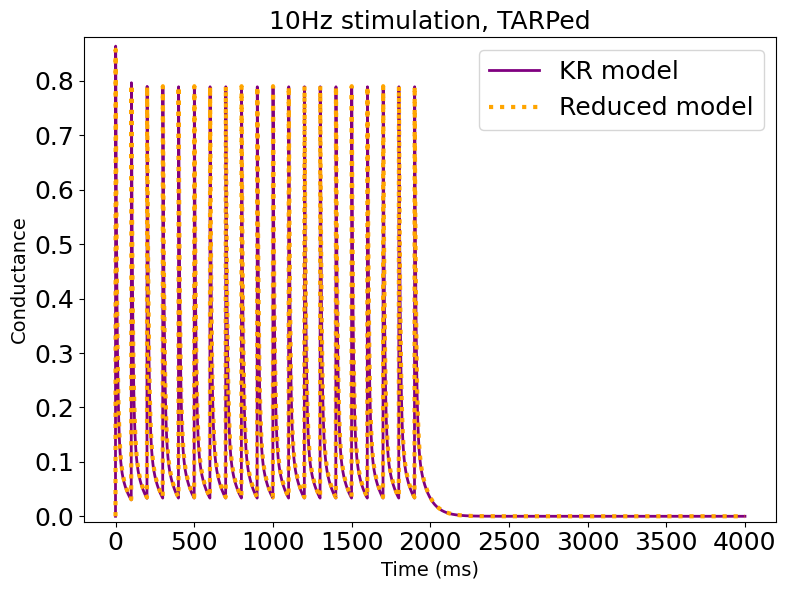

In [86]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 10, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 10, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('10Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [87]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [88]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print('AUC = ', np.abs((area_RH-area)/area_RH))

AUC =  0.03519173462661569


In [89]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.001794195264142874


In [90]:
# RMSE

print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))


RMSE =  0.02173892598392319


In [91]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.987821399370146


### 20Hz TARPed

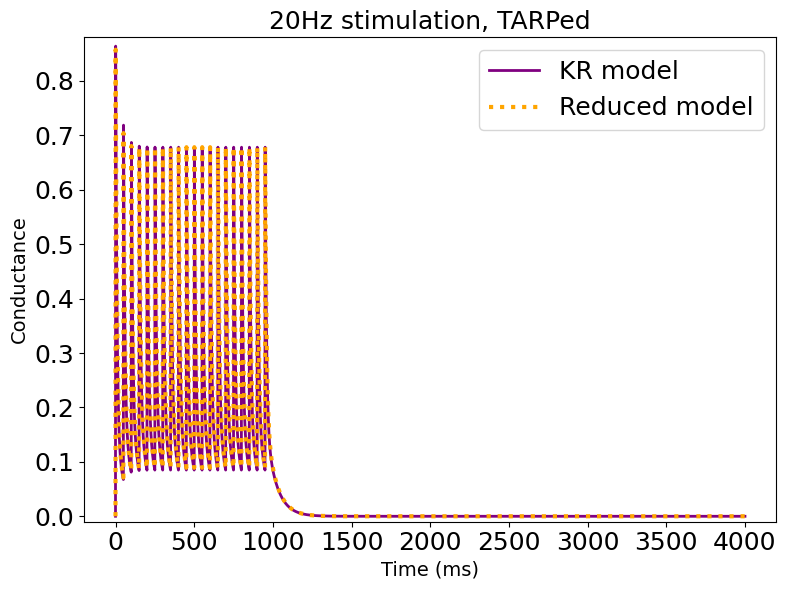

In [92]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (1, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 20, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (1, 20, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)



plt.figure(figsize=(8,6))

plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle='-', color='purple', linewidth=2)
plt.plot(sol_norm4.t[:], sol_norm4.y[2,:] + sol_norm4.y[3,:], label='Reduced model', linestyle=':', color='orange', linewidth=3)


plt.legend()
plt.title('20Hz stimulation, TARPed', fontsize=18)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Conductance', fontsize=14)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.ylim(-0.01, 0.88)
# plt.yscale('log')
plt.tight_layout()

In [93]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]

In [94]:
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print('AUC = ', np.abs((area_RH-area)/area_RH))

AUC =  0.027595139115407025


In [95]:
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))

Peak error 0.0021842952819123977


In [96]:
# RMSE

print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))


RMSE =  0.017401758119730302


In [97]:
# R^2

print('R^2 = ', r2_score(KR, red))

R^2 =  0.9902701587538938


### Poisson

In [53]:
def generate_poisson_timestamps(rate_hz, total_time_ms, seed=None):
    """
    Generates event timestamps (in ms) where ISIs are exponentially distributed.
    
    Parameters:
    - rate_hz: Average firing rate in Hz.
    - total_time_ms: Total duration of the generated spike train in ms.
    - t_start: Time offset for the first ISI (default 0 ms).
    - seed: Optional random seed for reproducibility.
    """
    if seed is not None:
        np.random.seed(seed)
        
    mean_isi_ms = 1000.0 / rate_hz
    
    # Make more than necessary
    estimated_n = int((total_time_ms / mean_isi_ms) * 3)
    
    # Generate ISIs and sum them up
    isis = np.random.exponential(scale=mean_isi_ms, size=estimated_n)
    timestamps = np.cumsum(isis)

    
    # Filter out timestamps exceeding total_time_ms
    return timestamps[timestamps <= (total_time_ms)]

In [54]:
# An average of 10Hz stimulation fro 4 seconds
t2 = generate_poisson_timestamps(rate_hz=10, total_time_ms=4000, seed=0)
t2 = t2[:20]

In [57]:
# TARPless

rmse_array = np.array([])
area_array = np.array([])
peaks_array = np.array([])
r_2_array = np.array([])

for i in range(10):


	t2 = generate_poisson_timestamps(rate_hz=10, total_time_ms=4000, seed=i)

	# 1 pulse
	alpha=6
	solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (4, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, t2, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


	# U_0 can vary
	tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
	tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
	y2=[1, U_0, 0, 0]
	sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, tauX, tauU, tauK, taug, A1, A2, alpha, U_0, 1, 0.9), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)




	red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
	KR = solRH.y[2,:] + 2*solRH.y[5,:]
	# Area under curve

	area = simpson(red, sol_norm4.t[:])
	area_RH = simpson(KR, solRH.t[:])
	# print('AUC = ', np.abs((area_RH-area)/area_RH))
	area_array = np.append(area_array, np.abs((area_RH-area)/area_RH))


	# Normalised peak error

	peaksKR = np.array([])
	peaksred = np.array([])

	for i in range(1, len(red)-1):
		if KR[i-1] < KR[i] > KR[i+1]:
			# print(KR[i])
			peaksKR = np.append(peaksKR, [KR[i]])
		if red[i-1] < red[i] > red[i+1]:
			peaksred = np.append(peaksred, [red[i]])

	# print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
	peaks_array = np.append(peaks_array, np.mean(np.abs((peaksKR-peaksred)/peaksKR)))


	# RMSE

	# print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))
	rmse_array = np.append(rmse_array, np.sqrt(np.mean((KR - red) ** 2)))

	# R^2
	r_2_array = np.append(r_2_array, r2_score(KR, red))


print('Mean AUC error = ', np.mean(area_array))
print('Mean Peak error = ', np.mean(peaks_array))
print('Mean RMSE = ', np.mean(rmse_array))
print('Mean R^2 = ', np.mean(r_2_array))


Mean AUC error =  0.0018629941190456544
Mean Peak error =  0.05247506258900303
Mean RMSE =  0.0060485684522451465
Mean R^2 =  0.9837062381418071


In [13]:
# TARPed


rmse_array = np.array([])
area_array = np.array([])
peaks_array = np.array([])
r_2_array = np.array([])

for i in range(10):


	t2 = generate_poisson_timestamps(rate_hz=10, total_time_ms=4000, seed=i)

	# 1 pulse
	alpha=6
	solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (4, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, t2, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


	tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
	taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
	y2 = [1, U_0 ,0 ,0]
	sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)




	red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
	KR = solRH.y[2,:] + 2*solRH.y[5,:]
	# Area under curve

	area = simpson(red, sol_norm4.t[:])
	area_RH = simpson(KR, solRH.t[:])
	# print('AUC = ', np.abs((area_RH-area)/area_RH))
	area_array = np.append(area_array, np.abs((area_RH-area)/area_RH))


	# Normalised peak error

	peaksKR = np.array([])
	peaksred = np.array([])

	for i in range(1, len(red)-1):
		if KR[i-1] < KR[i] > KR[i+1]:
			# print(KR[i])
			peaksKR = np.append(peaksKR, [KR[i]])
		if red[i-1] < red[i] > red[i+1]:
			peaksred = np.append(peaksred, [red[i]])

	# print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
	peaks_array = np.append(peaks_array, np.mean(np.abs((peaksKR-peaksred)/peaksKR)))


	# RMSE

	# print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))
	rmse_array = np.append(rmse_array, np.sqrt(np.mean((KR - red) ** 2)))

	# R^2
	r_2_array = np.append(r_2_array, r2_score(KR, red))


print('Mean AUC error = ', np.mean(area_array))
print('Mean Peak error = ', np.mean(peaks_array))
print('Mean RMSE = ', np.mean(rmse_array))
print('Mean R^2 = ', np.mean(r_2_array))

Mean AUC error =  0.03742339494155044
Mean Peak error =  0.01904678262436578
Mean RMSE =  0.02811578762531152
Mean R^2 =  0.9845817060861366


In [30]:
# An average of 10Hz stimulation fro 4 seconds
t2 = generate_poisson_timestamps(rate_hz=10, total_time_ms=4000, seed=0)
t2 = t2[:20]

In [92]:
# TARPless

rmse_array = np.array([])
area_array = np.array([])
peaks_array = np.array([])
r_2_array = np.array([])


# 1 pulse
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (4, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, t2, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# U_0 can vary
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, tauX, tauU, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)




red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
# print('AUC = ', np.abs((area_RH-area)/area_RH))
area_array = np.append(area_array, np.abs((area_RH-area)/area_RH))


# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
		print(i)

	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

# print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
peaks_array = np.append(peaks_array, np.mean(np.abs((peaksKR-peaksred)/peaksKR)))


# RMSE

# print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))
rmse_array = np.append(rmse_array, np.sqrt(np.mean((KR - red) ** 2)))

# R^2
r_2_array = np.append(r_2_array, r2_score(KR, red))


print('Mean AUC error = ', np.mean(area_array))
# print('Mean Peak error = ', np.mean(peaks_array))
print('Mean RMSE = ', np.mean(rmse_array))
print('Mean R^2 = ', np.mean(r_2_array))


Mean AUC error =  0.03189906695751286
Mean RMSE =  0.0018600575577534875
Mean R^2 =  0.9831077849220438


In [19]:
# TARPed


rmse_array = np.array([])
area_array = np.array([])
peaks_array = np.array([])
r_2_array = np.array([])



# 1 pulse
alpha=6
solRH = solve_ivp(Milstein2007, [0, 4000], y3, args = (4, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, t2, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 4000], y2, args =  (4, t2, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)




red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
# print('AUC = ', np.abs((area_RH-area)/area_RH))
area_array = np.append(area_array, np.abs((area_RH-area)/area_RH))


# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

# print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
peaks_array = np.append(peaks_array, np.mean(np.abs((peaksKR-peaksred)/peaksKR)))


# RMSE

# print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))
rmse_array = np.append(rmse_array, np.sqrt(np.mean((KR - red) ** 2)))

# R^2
r_2_array = np.append(r_2_array, r2_score(KR, red))


print('Mean AUC error = ', np.mean(area_array))
print('Mean Peak error = ', np.mean(peaks_array))
print('Mean RMSE = ', np.mean(rmse_array))
print('Mean R^2 = ', np.mean(r_2_array))

Mean AUC error =  0.036648643092459764
Mean Peak error =  0.014580068593948555
Mean RMSE =  0.021209794768837165
Mean R^2 =  0.9883892622213938


### Glutamates

In [131]:
rmse_array = np.array([])
area_array = np.array([])
peaks_array = np.array([])
r_2_array = np.array([])



# KR model
for i, j in np.array([[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], [0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1]]).T:
	alpha=6
	solRH = solve_ivp(Milstein2007, [0, 50], y3, args = (0, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 1, 1.1, 0.3, 0.1*i), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)



	tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
	taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
	y2=[1, U_0, 0, 0]
	sol_norm4 = solve_ivp(time_2first_ord, [0, 50], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, 1*j), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)
# (np.sqrt(i)-0.1)


	red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
	KR = solRH.y[2,:] + 2*solRH.y[5,:]

    
	# Area under curve
	area = simpson(red, sol_norm4.t[:])
	area_RH = simpson(KR, solRH.t[:])
	# print('AUC = ', np.abs((area_RH-area)/area_RH))
	area_array = np.append(area_array, np.abs((area_RH-area)/area_RH))


	# Normalised peak error
	peaksKR = np.array([])
	peaksred = np.array([])

	for i in range(1, len(red)-1):
		if KR[i-1] < KR[i] > KR[i+1]:
			peaksKR = np.append(peaksKR, [KR[i]])
		if red[i-1] < red[i] > red[i+1]:
			peaksred = np.append(peaksred, [red[i]])

	# print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
	peaks_array = np.append(peaks_array, np.mean(np.abs((peaksKR-peaksred)/peaksKR)))


	# RMSE
	# print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))
	rmse_array = np.append(rmse_array, np.sqrt(np.mean((KR - red) ** 2)))

	# R^2
	r_2_array = np.append(r_2_array, r2_score(KR, red))


print(' RMSE = ', (rmse_array))
print(' R^2 = ', (r_2_array))
print(' AUC error = ', (area_array))
print(' Peak error = ', (peaks_array))


 RMSE =  [0.00228083 0.00826913 0.00546842 0.00622611 0.00980517 0.01429383
 0.01461831 0.01740996 0.02088457 0.02326147]
 R^2 =  [0.99628038 0.98353131 0.99619229 0.99633889 0.99282624 0.98621511
 0.98616711 0.98337072 0.97727858 0.97255753]
 AUC error =  [0.01829587 0.12561629 0.04632164 0.03870299 0.05864389 0.09110516
 0.08000944 0.08001777 0.08702096 0.09856615]
 Peak error =  [0.01320403 0.12944973 0.06195165 0.06471149 0.0942815  0.13458747
 0.12749785 0.1282451  0.13385813 0.14260668]


In [133]:
rmse_array = np.array([])
area_array = np.array([])
peaks_array = np.array([])
r_2_array = np.array([])


# KR model
for i, j in np.array([[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], [0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1]]).T:
	alpha=6
	solRH = solve_ivp(Milstein2007, [0, 500], y3, args = (0, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 1, 1.1, 0.3, 0.1*i), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)



	tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
	taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
	y2 = [1, U_0 ,0 ,0]
	sol_norm4 = solve_ivp(time_2first_ord, [0, 500], y2, args =  (0, 1, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, 1*j), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)




	red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
	KR = solRH.y[2,:] + 2*solRH.y[5,:]

    
	# Area under curve
	area = simpson(red, sol_norm4.t[:])
	area_RH = simpson(KR, solRH.t[:])
	# print('AUC = ', np.abs((area_RH-area)/area_RH))
	area_array = np.append(area_array, np.abs((area_RH-area)/area_RH))


	# Normalised peak error
	peaksKR = np.array([])
	peaksred = np.array([])

	for i in range(1, len(red)-1):
		if KR[i-1] < KR[i] > KR[i+1]:
			peaksKR = np.append(peaksKR, [KR[i]])
		if red[i-1] < red[i] > red[i+1]:
			peaksred = np.append(peaksred, [red[i]])
	# print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
	peaks_array = np.append(peaks_array, np.mean(np.abs((peaksKR-peaksred)/peaksKR)))


	# RMSE
	# print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))
	rmse_array = np.append(rmse_array, np.sqrt(np.mean((KR - red) ** 2)))

	# R^2
	r_2_array = np.append(r_2_array, r2_score(KR, red))


print(' RMSE = ', (rmse_array))
print(' R^2 = ', (r_2_array))
print(' AUC error = ', (area_array))
print(' Peak error = ', (peaks_array))


 RMSE =  [0.00119374 0.00357039 0.00462604 0.00784471 0.00759853 0.0094373
 0.01280886 0.01422963 0.01557068 0.01655486]
 R^2 =  [0.99901544 0.99700806 0.99708514 0.99368291 0.99529417 0.99447665
 0.99145648 0.9895664  0.98846947 0.98719196]
 AUC error =  [0.01160225 0.07989527 0.00669398 0.02241433 0.01083196 0.01326577
 0.00527258 0.00750237 0.01610103 0.02870369]
 Peak error =  [0.03389519 0.03214909 0.04925035 0.06307642 0.05085889 0.02671921
 0.0331643  0.02990006 0.020625   0.00757851]


##### Long glutamate

In [140]:
# Reduced model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 150], y3, args = (3, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 100, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
tauX, tauU, U_0 = [426.05575527,   0.66710861,   0.62727836]
y2=[1, U_0, 0, 0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 150], y2, args =  (3, 100, tauX, tauU, tauK, taug, A1, A2, alpha, U_0, 1, 1.0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)


In [141]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print('AUC = ', np.abs((area_RH-area)/area_RH))
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
# RMSE

print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))

# R^2

print('R^2 = ', r2_score(KR, red))

AUC =  0.06798253784201257
Peak error 0.16050308453033876
RMSE =  0.01766778028980631
R^2 =  0.9581118974370972


In [142]:
# KR model
alpha=6
solRH = solve_ivp(Milstein2007, [0, 500], y3, args = (3, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 100, 1.1, 0.3, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


# Reduced model
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y2 = [1, U_0 ,0 ,0]
sol_norm4 = solve_ivp(time_2first_ord, [0, 500], y2, args =  (3, 100, taux, tauu, tauK, taug, A1, A2, alpha, U_0, 1, 1), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.1)


In [143]:
red = sol_norm4.y[2,:] + sol_norm4.y[3,:]
KR = solRH.y[2,:] + 2*solRH.y[5,:]
# Area under curve

area = simpson(red, sol_norm4.t[:])
area_RH = simpson(KR, solRH.t[:])
print('AUC = ', np.abs((area_RH-area)/area_RH))
# Normalised peak error

peaksKR = np.array([])
peaksred = np.array([])

for i in range(1, len(red)-1):
	if KR[i-1] < KR[i] > KR[i+1]:
		# print(KR[i])
		peaksKR = np.append(peaksKR, [KR[i]])
	if red[i-1] < red[i] > red[i+1]:
		peaksred = np.append(peaksred, [red[i]])

print('Peak error', np.mean(np.abs((peaksKR-peaksred)/peaksKR)))
# RMSE

print('RMSE = ',np.sqrt(np.mean((KR - red) ** 2)))

# R^2

print('R^2 = ', r2_score(KR, red))

AUC =  0.05194467271163355
Peak error 0.4056542530716407
RMSE =  0.03410832787090186
R^2 =  0.9761881988600757
